# Reviewer Rebuttal Experiments (Non-Causal)

This notebook implements requested reviewer analyses without causal modeling.

Covered items:
1) top_p ablation (temperature x top_p main table)
2) significance tests / confidence intervals for Exp 2-B and Exp 2-C style comparisons
3) independent ambiguity subset (temperature-independent)
4) AGR / format-error separation analysis
5) human-ambiguous case study (20-50 samples) with lightweight linguistic feature summary

In [1]:
from __future__ import annotations
from pathlib import Path
import json
import re
from typing import Iterable

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', context='talk')

BASE_DIR = Path('..')
OUT_DIR = BASE_DIR / 'output'
FIG_DIR = OUT_DIR / 'supplementary_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

VALID_VERDICTS = {'A', 'B', 'C'}
GOLD_MAP = {'model_a': 'A', 'model_b': 'B', 'tie': 'C'}
TARGET_JUDGE_MODEL = 'google/gemma-3-27b-it'

KEY_TEMPS = [0.01, 1.0, 1.5, 2.0, 3.0]
HIGH_SINGLE_TEMPS = [1.5, 2.0, 3.0]

PIPELINES = {
    'SP-Low (T=0.01,N=1)':    {'temps': [0.01], 'repeats': [0],             'agg': 'single'},
    'SP-Mid (T=1.0,N=1)':     {'temps': [1.0],  'repeats': [0],             'agg': 'single'},
    'Ens-Low (T=0.01,N=10)':  {'temps': [0.01], 'repeats': list(range(10)), 'agg': 'majority_vote'},
    'Ens-High (T=1.5,N=10)':  {'temps': [1.5],  'repeats': list(range(10)), 'agg': 'majority_vote'},
    'Ens-High (T=2.0,N=10)':  {'temps': [2.0],  'repeats': list(range(10)), 'agg': 'majority_vote'},
    'Ens-High (T=3.0,N=10)':  {'temps': [3.0],  'repeats': list(range(10)), 'agg': 'majority_vote'},
    'Ens-Mixed (Mix-T,N=15)': {'temps': [0.5, 1.0, 1.5, 2.0, 3.0], 'repeats': [0, 1, 2], 'agg': 'majority_vote'},
}

print('Imports OK')

Imports OK


In [2]:
def load_combined_dataset() -> pd.DataFrame:
    candidates = [
        OUT_DIR / 'combined_judge_dataset_qwen_gemma.csv',
        BASE_DIR / 'output' / 'combined_judge_dataset_qwen_gemma.csv',
    ]
    path = next((p for p in candidates if p.exists()), None)
    if path is None:
        raise FileNotFoundError('Cannot find output/combined_judge_dataset_qwen_gemma.csv')

    out = pd.read_csv(path)

    # Keep backward-compatible columns for downstream analysis cells.
    if 'top_p' not in out.columns:
        out['top_p'] = 0.95
    out['top_p'] = pd.to_numeric(out['top_p'], errors='coerce').fillna(0.95).astype(float)

    out['temperature'] = pd.to_numeric(out['temperature'], errors='coerce').astype(float)
    out['repeat_id'] = pd.to_numeric(out['repeat_id'], errors='coerce').fillna(0).astype(int)
    out['judge_type'] = out['judge_type'].astype(str)
    out['prompt_variant'] = out['prompt_variant'].astype(str)

    if 'pairwise_winner' not in out.columns:
        out['pairwise_winner'] = pd.Series(index=out.index, dtype='object')
    out['pairwise_winner'] = out['pairwise_winner'].astype(str)

    if 'gold_abc' not in out.columns:
        out['gold_abc'] = out['gold_winner'].map(GOLD_MAP)

    if 'format_error' not in out.columns:
        out['format_error'] = True
    out['format_error'] = out['format_error'].astype(bool)

    out['is_parseable'] = (~out['format_error']) & (out['pairwise_winner'].isin(VALID_VERDICTS))
    out['verdict'] = np.where(out['is_parseable'], out['pairwise_winner'], np.nan)

    if 'source_file' not in out.columns:
        out['source_file'] = path.name

    print(f'Loaded combined dataset from: {path}')
    return out


df_all = load_combined_dataset().copy()

print(f'Loaded rows (all judge models): {len(df_all):,}')
print('judge_model:', sorted(df_all['judge_model'].astype(str).unique().tolist()))
print('top_p values:', sorted(df_all['top_p'].dropna().unique().tolist()))
print('judge_type:', sorted(df_all['judge_type'].unique().tolist()))
print('prompt_variant:', sorted(df_all['prompt_variant'].unique().tolist()))

Loaded combined dataset from: ../output/combined_judge_dataset_qwen_gemma.csv
Loaded rows (all judge models): 360,000
judge_model: ['Qwen/Qwen3-Next-80B-A3B-Instruct-FP8', 'google/gemma-3-27b-it']
top_p values: [0.95]
judge_type: ['pairwise', 'reference_guided', 'single_answer']
prompt_variant: ['baseline', 'cot']


## 2.1 top_p = 1.0 Ablation (Temperature x top_p)

Main table is built on pairwise + baseline only.

If `top_p=1.0` files are missing, the table still runs for available top_p values and prints warnings.

In [3]:
def verdict_entropy(series: pd.Series) -> float:
    s = series.dropna()
    s = s[s.isin(VALID_VERDICTS)]
    if len(s) == 0:
        return np.nan
    p = s.value_counts(normalize=True)
    return float(-(p * np.log2(p + 1e-12)).sum())


def majority_verdict(series: pd.Series):
    s = series.dropna()
    s = s[s.isin(VALID_VERDICTS)]
    if len(s) == 0:
        return np.nan
    return s.value_counts().idxmax()


pw_base = df_all[(df_all['judge_type'] == 'pairwise') & (df_all['prompt_variant'] == 'baseline')].copy()
grp_cols = ['top_p', 'question_id', 'judge_model', 'temperature']

agg_q = (
    pw_base.groupby(grp_cols)
    .agg(
        final_verdict=('verdict', majority_verdict),
        vote_entropy=('verdict', verdict_entropy),
        format_error_rate=('format_error', lambda x: float(pd.Series(x).astype(float).mean())),
        gold_abc=('gold_abc', 'first'),
    )
    .reset_index()
)
agg_q['AGR'] = ((agg_q['final_verdict'] == agg_q['gold_abc']) & agg_q['final_verdict'].notna()).astype(float)

top_p_main = (
    agg_q[agg_q['temperature'].isin(KEY_TEMPS)]
    .groupby(['temperature', 'top_p'])
    .agg(
        AGR=('AGR', 'mean'),
        Vote_Entropy=('vote_entropy', 'mean'),
        Format_Error_Rate=('format_error_rate', 'mean'),
        N=('AGR', 'count'),
    )
    .reset_index()
    .sort_values(['temperature', 'top_p'])
)

print('=== Temperature x top_p Main Table (Pairwise, Baseline, Gemma-3-27B-It only) ===')
display(top_p_main.round(4))

=== Temperature x top_p Main Table (Pairwise, Baseline, Gemma-3-27B-It only) ===


,temperature,top_p,AGR,Vote_Entropy,Format_Error_Rate,N
0,0.0100,0.9500,0.6010,0.0257,0.0000,1000
1,1.0000,0.9500,0.6000,0.0609,0.0000,1000
2,1.5000,0.9500,0.5990,0.0989,0.0010,1000
3,2.0000,0.9500,0.6030,0.1496,0.0061,1000
4,3.0000,0.9500,0.6000,0.2976,0.0505,1000


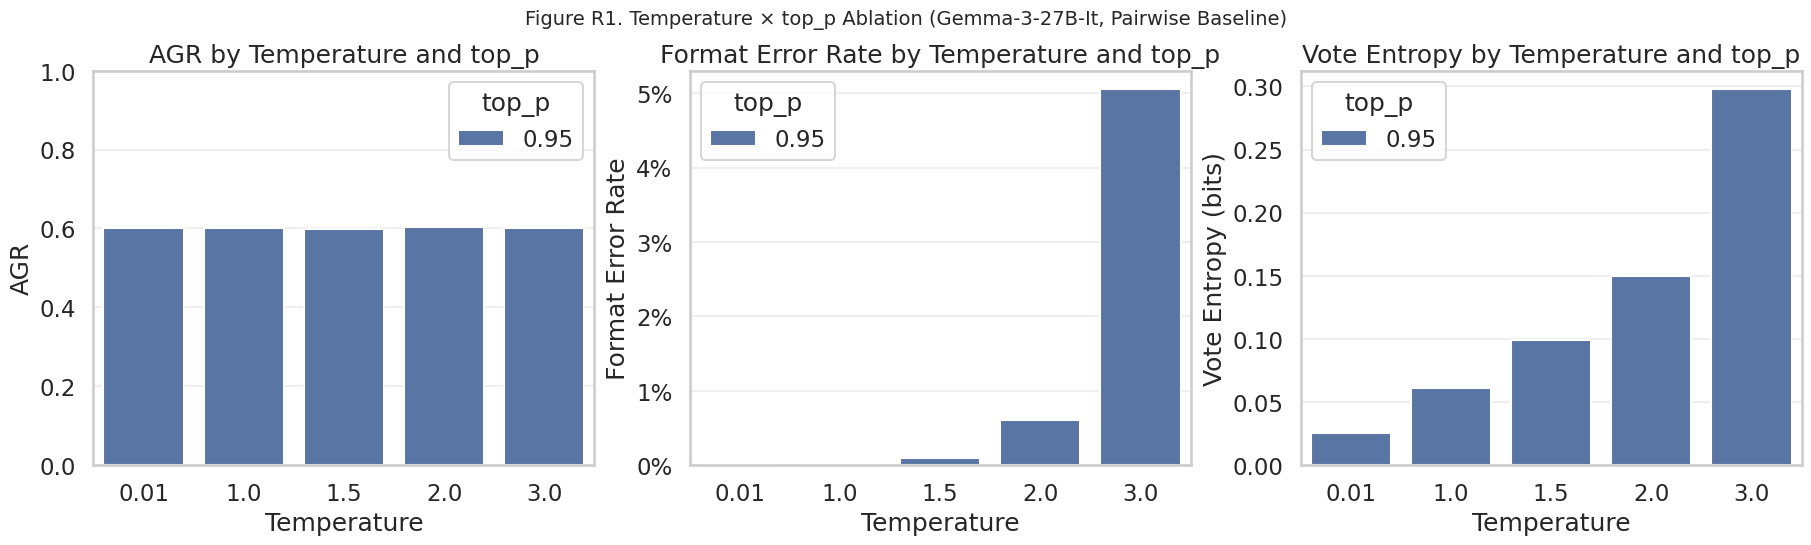

Saved: r1_top_p_ablation_gemma.png


In [40]:
# Academic-style visualization for 2.1
plot_df = top_p_main.copy()
plot_df['temp_str'] = plot_df['temperature'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)

sns.barplot(data=plot_df, x='temperature', y='AGR', hue='top_p', ax=axes[0], palette='deep')
axes[0].set_title('AGR by Temperature and top_p')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('AGR')
axes[0].set_ylim(0, 1)
axes[0].legend(title='top_p')
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=plot_df, x='temperature', y='Format_Error_Rate', hue='top_p', ax=axes[1], palette='deep')
axes[1].set_title('Format Error Rate by Temperature and top_p')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Format Error Rate')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
axes[1].legend(title='top_p')
axes[1].grid(axis='y', alpha=0.3)

sns.barplot(data=plot_df, x='temperature', y='Vote_Entropy', hue='top_p', ax=axes[2], palette='deep')
axes[2].set_title('Vote Entropy by Temperature and top_p')
axes[2].set_xlabel('Temperature')
axes[2].set_ylabel('Vote Entropy (bits)')
axes[2].legend(title='top_p')
axes[2].grid(axis='y', alpha=0.3)

fig.suptitle('Figure R1. Temperature × top_p Ablation (Gemma-3-27B-It, Pairwise Baseline)', fontsize=14, y=1.06)
plt.savefig(FIG_DIR / 'r1_top_p_ablation_gemma.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: r1_top_p_ablation_gemma.png')

## 2.3 Independent Ambiguity Subset (Temperature-Independent)

This subset uses only external signals independent from judge temperature behavior:
- human tie label (`human_winner == tie`)
- lexical overlap between answer A/B
- response length similarity

In [4]:
WORD_RE = re.compile(r'\w+', re.UNICODE)


def toks(x: str) -> set[str]:
    return set(WORD_RE.findall(str(x).lower()))


def jaccard(a: str, b: str) -> float:
    sa, sb = toks(a), toks(b)
    if not sa and not sb:
        return 0.0
    return len(sa & sb) / max(len(sa | sb), 1)


anchor = (
    pw_base.sort_values(['question_id', 'repeat_id', 'temperature'])
    .drop_duplicates(subset=['question_id'])
    [['question_id', 'answer_a_text', 'answer_b_text', 'human_winner']]
    .copy()
)

anchor['len_a'] = anchor['answer_a_text'].astype(str).str.len()
anchor['len_b'] = anchor['answer_b_text'].astype(str).str.len()
anchor['len_ratio_close'] = (
    (anchor[['len_a', 'len_b']].min(axis=1) / anchor[['len_a', 'len_b']].max(axis=1).clip(lower=1)) >= 0.85
).astype(int)
anchor['lex_overlap'] = anchor.apply(lambda r: jaccard(r['answer_a_text'], r['answer_b_text']), axis=1)
anchor['high_overlap'] = (anchor['lex_overlap'] >= 0.22).astype(int)
anchor['human_tie'] = (anchor['human_winner'].astype(str) == 'tie').astype(int)
anchor['uncertainty_proxy'] = anchor['human_tie'] + anchor['high_overlap'] + anchor['len_ratio_close']

anchor['ambiguous_independent'] = (anchor['uncertainty_proxy'] >= 2)

amb_qids = set(anchor.loc[anchor['ambiguous_independent'], 'question_id'])
nonamb_qids = set(anchor['question_id']) - amb_qids

print(f'Independent ambiguous questions: {len(amb_qids):,} / {anchor.question_id.nunique():,}')
display(anchor[['human_tie', 'high_overlap', 'len_ratio_close', 'uncertainty_proxy', 'ambiguous_independent']].mean().to_frame('mean'))

Independent ambiguous questions: 153 / 500


,mean
human_tie,0.2660
high_overlap,0.5600
len_ratio_close,0.1760
uncertainty_proxy,1.0020
ambiguous_independent,0.3060


In [5]:
# 2.3 extension (revised): Direct vs CoT AGR table using supplementary-style ambiguity definition
# Key alignment with supplementary_experiments:
# 1) Ambiguous defined by entropy dynamics (not text heuristics)
# 2) Amb/Non-Amb subset keyed by question_id (shared across Direct and CoT)
# 3) Metrics still aggregated per (question_id, judge_model)

META_COLS = ['question_id', 'judge_model', 'prompt_variant']
LOW_ENT_THRESH = 0.01
HIGH_ENT_THRESH = 0.50
HIGH_T = [1.5, 2.0, 3.0]

pw_095 = df_all[(df_all['judge_type'] == 'pairwise') & (df_all['top_p'] == 0.95)].copy()

# Per-(qid,model,prompt,temp) entropy profile
ent = (
    pw_095.groupby(META_COLS + ['temperature'])
    .agg(
        entropy=('verdict', verdict_entropy),
        majority=('verdict', majority_verdict),
    )
    .reset_index()
)

low_info = (
    ent[ent['temperature'] == 0.01][META_COLS + ['entropy', 'majority']]
    .rename(columns={'entropy': 'ent_low', 'majority': 'maj_low'})
)

high_info = (
    ent[ent['temperature'].isin(HIGH_T)]
    .groupby(META_COLS)
    .agg(ent_high_mean=('entropy', 'mean'), ent_high_max=('entropy', 'max'))
    .reset_index()
)

high_maj = (
    pw_095[pw_095['temperature'].isin(HIGH_T)]
    .groupby(META_COLS)['verdict']
    .apply(majority_verdict)
    .reset_index()
    .rename(columns={'verdict': 'maj_high'})
)

sample_df_exp2 = (
    low_info
    .merge(high_info, on=META_COLS, how='inner')
    .merge(high_maj, on=META_COLS, how='inner')
)

sample_df_exp2['ambiguous'] = (sample_df_exp2['ent_low'] < LOW_ENT_THRESH) & (sample_df_exp2['ent_high_mean'] > HIGH_ENT_THRESH)
sample_df_exp2['non_ambiguous'] = (sample_df_exp2['ent_low'] < LOW_ENT_THRESH) & (sample_df_exp2['ent_high_mean'] <= HIGH_ENT_THRESH)

print('=== Supplementary-style ambiguity split (top_p=0.95, pairwise) ===')
print(f"Total (qid x model x prompt): {len(sample_df_exp2):,}")
display(
    sample_df_exp2.groupby('prompt_variant')[['ambiguous', 'non_ambiguous']]
    .agg(n_ambiguous=('ambiguous', 'sum'), n_non_ambiguous=('non_ambiguous', 'sum'), total=('ambiguous', 'count'))
    .assign(rate_amb=lambda d: d['n_ambiguous'] / d['total'])
    .round(4)
)

# Legacy-compatible subset index: question_id only (shared across prompts and models)
AMB_IDS = set(sample_df_exp2.loc[sample_df_exp2['ambiguous'], 'question_id'].unique())
ALL_QIDS = set(df_all['question_id'].unique())
NONAMB_IDS = ALL_QIDS - AMB_IDS

print('\n=== Legacy subset index (question_id) ===')
print(f'Ambiguous question IDs     : {len(AMB_IDS):,}')
print(f'Non-Ambiguous question IDs : {len(NONAMB_IDS):,}')


def compute_pipeline_metrics_exp2(df_sub: pd.DataFrame, agg_mode: str) -> pd.DataFrame:
    rows = []
    for (qid, model), g in df_sub.groupby(['question_id', 'judge_model']):
        valid = g['verdict']
        gold = g['gold_abc'].iloc[0] if g['gold_abc'].notna().any() else np.nan

        if agg_mode == 'single':
            final_v = g['verdict'].iloc[0] if len(g) else np.nan
        else:
            final_v = majority_verdict(valid)

        agr = (1.0 if final_v == gold else 0.0) if (pd.notna(final_v) and pd.notna(gold)) else np.nan
        rows.append({
            'question_id': qid,
            'judge_model': model,
            'final_verdict': final_v,
            'AGR': agr,
            'vote_entropy': verdict_entropy(valid),
        })
    return pd.DataFrame(rows)


def run_pipelines_for_prompt_subset(pw_prompt: pd.DataFrame, qid_set: set[int]) -> dict[str, pd.DataFrame]:
    sub0 = pw_prompt[pw_prompt['question_id'].isin(qid_set)].copy()
    out = {}
    for name, cfg in PIPELINES.items():
        x = sub0[sub0['temperature'].isin(cfg['temps']) & sub0['repeat_id'].isin(cfg['repeats'])].copy()
        out[name] = compute_pipeline_metrics_exp2(x, cfg['agg'])
    return out


pw_base_095 = pw_095[pw_095['prompt_variant'] == 'baseline'].copy()
pw_cot_095 = pw_095[pw_095['prompt_variant'] == 'cot'].copy()

base_amb_res = run_pipelines_for_prompt_subset(pw_base_095, AMB_IDS)
base_non_res = run_pipelines_for_prompt_subset(pw_base_095, NONAMB_IDS)
cot_amb_res = run_pipelines_for_prompt_subset(pw_cot_095, AMB_IDS)
cot_non_res = run_pipelines_for_prompt_subset(pw_cot_095, NONAMB_IDS)


def build_table_rows(prompt_label: str, res_amb: dict[str, pd.DataFrame], res_non: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for pname in PIPELINES.keys():
        d_amb = res_amb[pname]
        d_non = res_non[pname]
        rows.append({
            'Prompt': prompt_label,
            'Pipeline': pname,
            'AGR (Amb)': d_amb['AGR'].mean() if len(d_amb) else np.nan,
            'AGR (Non-Amb)': d_non['AGR'].mean() if len(d_non) else np.nan,
            'N_Amb': len(d_amb),
            'N_NonAmb': len(d_non),
        })
    return pd.DataFrame(rows)


exp2_block = pd.concat([
    build_table_rows('Direct', base_amb_res, base_non_res),
    build_table_rows('Chain-of-Thought', cot_amb_res, cot_non_res),
], ignore_index=True)

prompt_order = ['Direct', 'Chain-of-Thought']
pipe_order = list(PIPELINES.keys())
exp2_block['Prompt'] = pd.Categorical(exp2_block['Prompt'], categories=prompt_order, ordered=True)
exp2_block['Pipeline'] = pd.Categorical(exp2_block['Pipeline'], categories=pipe_order, ordered=True)
exp2_block = exp2_block.sort_values(['Prompt', 'Pipeline']).reset_index(drop=True)

print('\n=== Direct vs CoT on supplementary-style Amb/Non-Amb split (AGR) ===')
display(exp2_block[['Prompt', 'Pipeline', 'AGR (Amb)', 'AGR (Non-Amb)', 'N_Amb', 'N_NonAmb']].round(4))

# Markdown-friendly table with prompt-block best values in bold markers
show_tbl = exp2_block[['Prompt', 'Pipeline', 'AGR (Amb)', 'AGR (Non-Amb)']].copy()
show_tbl['AGR (Amb)'] = show_tbl['AGR (Amb)'].astype(object)
show_tbl['AGR (Non-Amb)'] = show_tbl['AGR (Non-Amb)'].astype(object)
for p in prompt_order:
    m = show_tbl['Prompt'] == p
    best_amb = exp2_block.loc[exp2_block['Prompt'] == p, 'AGR (Amb)'].max()
    best_non = exp2_block.loc[exp2_block['Prompt'] == p, 'AGR (Non-Amb)'].max()
    show_tbl.loc[m, 'AGR (Amb)'] = exp2_block.loc[m, 'AGR (Amb)'].map(
        lambda v: f"**{v:.4f}**" if pd.notna(v) and abs(v - best_amb) < 1e-12 else f"{v:.4f}"
    ).to_list()
    show_tbl.loc[m, 'AGR (Non-Amb)'] = exp2_block.loc[m, 'AGR (Non-Amb)'].map(
        lambda v: f"**{v:.4f}**" if pd.notna(v) and abs(v - best_non) < 1e-12 else f"{v:.4f}"
    ).to_list()

print('\n=== Markdown-ready table values (best per prompt block highlighted) ===')
display(show_tbl)

# Coverage diagnostics (question_id-indexed subsets)
def coverage_for_prompt_subset(pw_prompt: pd.DataFrame, qid_set: set[int], prompt_name: str, subset_name: str) -> pd.DataFrame:
    sub0 = pw_prompt[pw_prompt['question_id'].isin(qid_set)].copy()
    n_units = sub0[['question_id', 'judge_model']].drop_duplicates().shape[0]
    rows = []
    for pname, cfg in PIPELINES.items():
        x = sub0[sub0['temperature'].isin(cfg['temps']) & sub0['repeat_id'].isin(cfg['repeats'])]
        expected = n_units * len(cfg['temps']) * len(cfg['repeats'])
        observed = len(x)
        rows.append({
            'Prompt': prompt_name,
            'Subset': subset_name,
            'Pipeline': pname,
            'Expected_rows': expected,
            'Observed_rows': observed,
            'Coverage': (observed / expected) if expected > 0 else np.nan,
        })
    return pd.DataFrame(rows)

cov_tbl = pd.concat([
    coverage_for_prompt_subset(pw_base_095, AMB_IDS, 'Direct', 'Amb'),
    coverage_for_prompt_subset(pw_base_095, NONAMB_IDS, 'Direct', 'Non-Amb'),
    coverage_for_prompt_subset(pw_cot_095, AMB_IDS, 'CoT', 'Amb'),
    coverage_for_prompt_subset(pw_cot_095, NONAMB_IDS, 'CoT', 'Non-Amb'),
], ignore_index=True)

print('\n=== Coverage diagnostics (supplementary-style split) ===')
display(cov_tbl.round(4))

save_tab = FIG_DIR / 'table_exp2_baseline_cot_block_new_ambig_split.csv'
save_cov = FIG_DIR / 'table_exp2_baseline_cot_block_coverage_diagnostics.csv'
exp2_block.to_csv(save_tab, index=False)
cov_tbl.to_csv(save_cov, index=False)
print(f'Saved: {save_tab}')
print(f'Saved: {save_cov}')

=== Supplementary-style ambiguity split (top_p=0.95, pairwise) ===
Total (qid x model x prompt): 2,000


,n_ambiguous,n_non_ambiguous,total,rate_amb
prompt_variant,,,,
baseline,116,852,1000,0.1160
cot,194,723,1000,0.1940



=== Legacy subset index (question_id) ===
Ambiguous question IDs     : 213
Non-Ambiguous question IDs : 287

=== Direct vs CoT on supplementary-style Amb/Non-Amb split (AGR) ===


,Prompt,Pipeline,AGR (Amb),AGR (Non-Amb),N_Amb,N_NonAmb
0,Direct,"SP-Low (T=0.01,N=1)",0.5141,0.6568,426,574
1,Direct,"SP-Mid (T=1.0,N=1)",0.5094,0.6551,426,574
2,Direct,"Ens-Low (T=0.01,N=10)",0.5188,0.6620,426,574
3,Direct,"Ens-High (T=1.5,N=10)",0.5235,0.6551,426,574
4,Direct,"Ens-High (T=2.0,N=10)",0.5305,0.6568,426,574
5,Direct,"Ens-High (T=3.0,N=10)",0.5258,0.6551,426,574
6,Direct,"Ens-Mixed (Mix-T,N=15)",0.5070,0.6585,426,574
7,Chain-of-Thought,"SP-Low (T=0.01,N=1)",0.4413,0.6456,426,574
8,Chain-of-Thought,"SP-Mid (T=1.0,N=1)",0.4240,0.6578,426,574
9,Chain-of-Thought,"Ens-Low (T=0.01,N=10)",0.4561,0.6509,426,574



=== Markdown-ready table values (best per prompt block highlighted) ===


,Prompt,Pipeline,AGR (Amb),AGR (Non-Amb)
0,Direct,"SP-Low (T=0.01,N=1)",0.5141,0.6568
1,Direct,"SP-Mid (T=1.0,N=1)",0.5094,0.6551
2,Direct,"Ens-Low (T=0.01,N=10)",0.5188,**0.6620**
3,Direct,"Ens-High (T=1.5,N=10)",0.5235,0.6551
4,Direct,"Ens-High (T=2.0,N=10)",**0.5305**,0.6568
5,Direct,"Ens-High (T=3.0,N=10)",0.5258,0.6551
6,Direct,"Ens-Mixed (Mix-T,N=15)",0.5070,0.6585
7,Chain-of-Thought,"SP-Low (T=0.01,N=1)",0.4413,0.6456
8,Chain-of-Thought,"SP-Mid (T=1.0,N=1)",0.4240,0.6578
9,Chain-of-Thought,"Ens-Low (T=0.01,N=10)",0.4561,0.6509



=== Coverage diagnostics (supplementary-style split) ===


,Prompt,Subset,Pipeline,Expected_rows,Observed_rows,Coverage
0,Direct,Amb,"SP-Low (T=0.01,N=1)",426,426,1.0000
1,Direct,Amb,"SP-Mid (T=1.0,N=1)",426,426,1.0000
2,Direct,Amb,"Ens-Low (T=0.01,N=10)",4260,4260,1.0000
3,Direct,Amb,"Ens-High (T=1.5,N=10)",4260,4260,1.0000
4,Direct,Amb,"Ens-High (T=2.0,N=10)",4260,4260,1.0000
5,Direct,Amb,"Ens-High (T=3.0,N=10)",4260,4260,1.0000
6,Direct,Amb,"Ens-Mixed (Mix-T,N=15)",6390,6390,1.0000
7,Direct,Non-Amb,"SP-Low (T=0.01,N=1)",574,574,1.0000
8,Direct,Non-Amb,"SP-Mid (T=1.0,N=1)",574,574,1.0000
9,Direct,Non-Amb,"Ens-Low (T=0.01,N=10)",5740,5740,1.0000


Saved: ../output/supplementary_figures/table_exp2_baseline_cot_block_new_ambig_split.csv
Saved: ../output/supplementary_figures/table_exp2_baseline_cot_block_coverage_diagnostics.csv


## 2.3-B LLM-defined Ambiguity Set (GPT-5.4 mini)

This section defines an additional ambiguity set using GPT-5.4 mini with a structured prompt,
stores question-level labels to disk, and builds the same Direct vs CoT AGR table on this new split.

Notes:
- API key is loaded from `.env` (or environment variables).
- Classification results are cached to avoid repeated API calls.
- Label space: `ambiguous`, `non_ambiguous`, `unsure` (unsure is excluded from both sets).

In [6]:
# 2.3-B: Build an additional ambiguity set via GPT-5.4 mini and evaluate Direct vs CoT AGR on that split.
import os
from pathlib import Path
import json
import time

try:
    from dotenv import load_dotenv  # optional helper
except Exception:
    load_dotenv = None

from jinja2 import Template
from openai import OpenAI

MODEL_NAME_LLM_AMBIG = 'gpt-5.4-mini'
LLM_LABEL_CACHE = FIG_DIR / 'ambiguity_gpt54mini_labels.csv'
LLM_LABEL_JSON = FIG_DIR / 'ambiguity_gpt54mini_labels.json'
LLM_TABLE_CSV = FIG_DIR / 'table_exp2_baseline_cot_block_gpt54mini_ambig_split.csv'
LLM_PROMPT_TEMPLATE_PATH = BASE_DIR / 'src' / 'llmjudgetempcausal' / 'assets' / 'user_ambiguity_labeling.jinja'

# You can reduce this for a quick smoke test (e.g., 50). None means all questions.
MAX_Q_FOR_LLM = None

def _load_api_key() -> str:
    if load_dotenv is not None:
        load_dotenv(BASE_DIR / '.env', override=False)
        load_dotenv(override=False)

    key = os.getenv('OPENAI_API_KEY') or os.getenv('GPT_API_KEY')
    if not key:
        raise RuntimeError(
            'Missing API key. Set OPENAI_API_KEY (or GPT_API_KEY) in environment or .env file.'
        )
    return key

if not LLM_PROMPT_TEMPLATE_PATH.exists():
    raise FileNotFoundError(f'Missing prompt template: {LLM_PROMPT_TEMPLATE_PATH}')
LLM_PROMPT_TEMPLATE = Template(LLM_PROMPT_TEMPLATE_PATH.read_text(encoding='utf-8'))

def _build_llm_ambiguity_prompt(row: pd.Series) -> str:
    return LLM_PROMPT_TEMPLATE.render(
        human_winner=str(row.get('human_winner', '')),
        answer_a=str(row.get('answer_a_text', '')),
        answer_b=str(row.get('answer_b_text', '')),
        reference_answer=str(row.get('reference_answer', '')),
    )

def _classify_one_question(client: OpenAI, row: pd.Series) -> dict:
    prompt = _build_llm_ambiguity_prompt(row)
    resp = client.responses.create(
        model=MODEL_NAME_LLM_AMBIG,
        input=[
            {
                'role': 'system',
                'content': 'You are a strict JSON classifier. Return valid JSON only, no markdown.',
            },
            {
                'role': 'user',
                'content': prompt,
            },
        ],
        temperature=0.0,
        max_output_tokens=220,
    )

    text = (getattr(resp, 'output_text', None) or '').strip()
    if not text:
        text = '{}'

    try:
        obj = json.loads(text)
    except Exception:
        obj = {'label': 'unsure', 'confidence': 0.0, 'rationale': f'parse_error: {text[:160]}'}

    label = str(obj.get('label', 'unsure')).strip().lower()
    if label not in {'ambiguous', 'non_ambiguous', 'unsure'}:
        label = 'unsure'

    conf = obj.get('confidence', 0.0)
    try:
        conf = float(conf)
    except Exception:
        conf = 0.0
    conf = min(max(conf, 0.0), 1.0)

    rationale = str(obj.get('rationale', '')).strip()
    return {'label': label, 'confidence': conf, 'rationale': rationale}

# Build a question-level anchor table.
anchor_llm = (
    pw_base.sort_values(['question_id', 'repeat_id', 'temperature'])
    .drop_duplicates(subset=['question_id'])
    [['question_id', 'answer_a_text', 'answer_b_text', 'reference_answer', 'human_winner']]
    .copy()
    .reset_index(drop=True)
)

if MAX_Q_FOR_LLM is not None:
    anchor_llm = anchor_llm.head(int(MAX_Q_FOR_LLM)).copy()

# Load old cache if present.
if LLM_LABEL_CACHE.exists():
    cache_df = pd.read_csv(LLM_LABEL_CACHE)
else:
    cache_df = pd.DataFrame(columns=['question_id', 'label', 'confidence', 'rationale', 'model'])

done_qids = set(pd.to_numeric(cache_df['question_id'], errors='coerce').dropna().astype(int).tolist())
todo = anchor_llm[~anchor_llm['question_id'].isin(done_qids)].copy()

print(f'Total questions for LLM ambiguity labeling: {len(anchor_llm):,}')
print(f'Already cached: {len(done_qids):,} | To query now: {len(todo):,}')

new_rows = []
if len(todo):
    api_key = _load_api_key()
    client = OpenAI(api_key=api_key)

    for i, (_, r) in enumerate(todo.iterrows(), start=1):
        out = _classify_one_question(client, r)
        new_rows.append({
            'question_id': int(r['question_id']),
            'label': out['label'],
            'confidence': out['confidence'],
            'rationale': out['rationale'],
            'model': MODEL_NAME_LLM_AMBIG,
        })
        if i % 20 == 0:
            print(f'  labeled {i:,}/{len(todo):,} new questions...')
        time.sleep(0.05)

if new_rows:
    new_df = pd.DataFrame(new_rows)
    all_labels = pd.concat([cache_df, new_df], ignore_index=True)
    all_labels = all_labels.sort_values(['question_id']).drop_duplicates(subset=['question_id'], keep='last').reset_index(drop=True)
else:
    all_labels = cache_df.copy()

all_labels.to_csv(LLM_LABEL_CACHE, index=False)
all_labels.to_json(LLM_LABEL_JSON, orient='records', force_ascii=False, indent=2)
print(f'Saved label cache: {LLM_LABEL_CACHE}')
print(f'Saved label json : {LLM_LABEL_JSON}')

# Build LLM-defined ambiguous / non-ambiguous sets.
llm_lab = all_labels.copy()
llm_lab['question_id'] = pd.to_numeric(llm_lab['question_id'], errors='coerce')
llm_lab = llm_lab.dropna(subset=['question_id']).copy()
llm_lab['question_id'] = llm_lab['question_id'].astype(int)

AMB_IDS_LLM = set(llm_lab.loc[llm_lab['label'] == 'ambiguous', 'question_id'])
NONAMB_IDS_LLM = set(llm_lab.loc[llm_lab['label'] == 'non_ambiguous', 'question_id'])
UNSURE_IDS_LLM = set(llm_lab.loc[llm_lab['label'] == 'unsure', 'question_id'])

print('\n=== GPT-5.4 mini ambiguity split (question_id-level) ===')
print(f'Ambiguous question IDs     : {len(AMB_IDS_LLM):,}')
print(f'Non-Ambiguous question IDs : {len(NONAMB_IDS_LLM):,}')
print(f'Unsure question IDs        : {len(UNSURE_IDS_LLM):,}')

# Evaluate Direct vs CoT AGR on the LLM-defined split (same style as 2.3 table).
pw_095_llm = df_all[(df_all['judge_type'] == 'pairwise') & (df_all['top_p'] == 0.95)].copy()
pw_base_llm = pw_095_llm[pw_095_llm['prompt_variant'] == 'baseline'].copy()
pw_cot_llm = pw_095_llm[pw_095_llm['prompt_variant'] == 'cot'].copy()

base_amb_llm = run_pipelines_for_prompt_subset(pw_base_llm, AMB_IDS_LLM)
base_non_llm = run_pipelines_for_prompt_subset(pw_base_llm, NONAMB_IDS_LLM)
cot_amb_llm = run_pipelines_for_prompt_subset(pw_cot_llm, AMB_IDS_LLM)
cot_non_llm = run_pipelines_for_prompt_subset(pw_cot_llm, NONAMB_IDS_LLM)

exp2_block_llm = pd.concat([
    build_table_rows('Direct', base_amb_llm, base_non_llm),
    build_table_rows('Chain-of-Thought', cot_amb_llm, cot_non_llm),
], ignore_index=True)

prompt_order = ['Direct', 'Chain-of-Thought']
pipe_order = list(PIPELINES.keys())
exp2_block_llm['Prompt'] = pd.Categorical(exp2_block_llm['Prompt'], categories=prompt_order, ordered=True)
exp2_block_llm['Pipeline'] = pd.Categorical(exp2_block_llm['Pipeline'], categories=pipe_order, ordered=True)
exp2_block_llm = exp2_block_llm.sort_values(['Prompt', 'Pipeline']).reset_index(drop=True)

print('\n=== Direct vs CoT on GPT-5.4 mini Amb/Non-Amb split (AGR) ===')
display(exp2_block_llm[['Prompt', 'Pipeline', 'AGR (Amb)', 'AGR (Non-Amb)', 'N_Amb', 'N_NonAmb']].round(4))

exp2_block_llm.to_csv(LLM_TABLE_CSV, index=False)
print(f'Saved: {LLM_TABLE_CSV}')

Total questions for LLM ambiguity labeling: 500
Already cached: 0 | To query now: 500
  labeled 20/500 new questions...
  labeled 40/500 new questions...
  labeled 60/500 new questions...
  labeled 80/500 new questions...
  labeled 100/500 new questions...
  labeled 120/500 new questions...
  labeled 140/500 new questions...
  labeled 160/500 new questions...
  labeled 180/500 new questions...
  labeled 200/500 new questions...
  labeled 220/500 new questions...
  labeled 240/500 new questions...
  labeled 260/500 new questions...
  labeled 280/500 new questions...
  labeled 300/500 new questions...
  labeled 320/500 new questions...
  labeled 340/500 new questions...
  labeled 360/500 new questions...
  labeled 380/500 new questions...
  labeled 400/500 new questions...
  labeled 420/500 new questions...
  labeled 440/500 new questions...
  labeled 460/500 new questions...
  labeled 480/500 new questions...
  labeled 500/500 new questions...
Saved label cache: ../output/supplementary_

,Prompt,Pipeline,AGR (Amb),AGR (Non-Amb),N_Amb,N_NonAmb
0,Direct,"SP-Low (T=0.01,N=1)",0.3438,0.6071,32,962
1,Direct,"SP-Mid (T=1.0,N=1)",0.3438,0.6040,32,962
2,Direct,"Ens-Low (T=0.01,N=10)",0.3438,0.6123,32,962
3,Direct,"Ens-High (T=1.5,N=10)",0.3438,0.6102,32,962
4,Direct,"Ens-High (T=2.0,N=10)",0.3438,0.6133,32,962
5,Direct,"Ens-High (T=3.0,N=10)",0.4062,0.6081,32,962
6,Direct,"Ens-Mixed (Mix-T,N=15)",0.3438,0.6050,32,962
7,Chain-of-Thought,"SP-Low (T=0.01,N=1)",0.2812,0.5744,32,962
8,Chain-of-Thought,"SP-Mid (T=1.0,N=1)",0.3333,0.5719,32,962
9,Chain-of-Thought,"Ens-Low (T=0.01,N=10)",0.2812,0.5813,32,962


Saved: ../output/supplementary_figures/table_exp2_baseline_cot_block_gpt54mini_ambig_split.csv


In [7]:
# 2.3-C: Looser GPT ambiguity definition (expect a larger ambiguous set)
from jinja2 import Template

MODEL_NAME_LLM_AMBIG_LOOSE = 'gpt-5.4-mini'
LLM_LABEL_CACHE_LOOSE = FIG_DIR / 'ambiguity_gpt54mini_labels_loose.csv'
LLM_LABEL_JSON_LOOSE = FIG_DIR / 'ambiguity_gpt54mini_labels_loose.json'
LLM_TABLE_CSV_LOOSE = FIG_DIR / 'table_exp2_baseline_cot_block_gpt54mini_ambig_split_loose.csv'

# Keep this None for full run; set small int for smoke test.
MAX_Q_FOR_LLM_LOOSE = None

LOOSE_PROMPT_TEMPLATE = Template("""You are labeling whether a model-comparison question is ambiguous.

Context:
- human_winner label (for context only): {{ human_winner }}
- Candidate Answer A:
{{ answer_a }}
- Candidate Answer B:
{{ answer_b }}
- Reference (if available):
{{ reference_answer }}

Task: choose exactly one label from
1) ambiguous
2) non_ambiguous
3) unsure

Looser ambiguity policy (important):
- Prefer 'ambiguous' whenever both answers are at least plausibly defensible under common evaluation criteria (correctness, completeness, faithfulness, clarity).
- If differences are small, style-based, or depend on subjective preference/weighting, label 'ambiguous'.
- Use 'non_ambiguous' only when one answer is clearly and robustly superior.
- Use 'unsure' only if information is insufficient or badly corrupted.

Return STRICT JSON only with schema:
{
  \"label\": \"ambiguous|non_ambiguous|unsure\",
  \"confidence\": <float between 0 and 1>,
  \"rationale\": \"<one short sentence>\"
}
""")

def _build_llm_ambiguity_prompt_loose(row: pd.Series) -> str:
    return LOOSE_PROMPT_TEMPLATE.render(
        human_winner=str(row.get('human_winner', '')),
        answer_a=str(row.get('answer_a_text', '')),
        answer_b=str(row.get('answer_b_text', '')),
        reference_answer=str(row.get('reference_answer', '')),
    )

def _classify_one_question_loose(client: OpenAI, row: pd.Series) -> dict:
    prompt = _build_llm_ambiguity_prompt_loose(row)
    resp = client.responses.create(
        model=MODEL_NAME_LLM_AMBIG_LOOSE,
        input=[
            {
                'role': 'system',
                'content': 'You are a strict JSON classifier. Return valid JSON only, no markdown.',
            },
            {
                'role': 'user',
                'content': prompt,
            },
        ],
        temperature=0.0,
        max_output_tokens=220,
    )

    text = (getattr(resp, 'output_text', None) or '').strip()
    if not text:
        text = '{}'

    try:
        obj = json.loads(text)
    except Exception:
        obj = {'label': 'unsure', 'confidence': 0.0, 'rationale': f'parse_error: {text[:160]}'}

    label = str(obj.get('label', 'unsure')).strip().lower()
    if label not in {'ambiguous', 'non_ambiguous', 'unsure'}:
        label = 'unsure'

    conf = obj.get('confidence', 0.0)
    try:
        conf = float(conf)
    except Exception:
        conf = 0.0
    conf = min(max(conf, 0.0), 1.0)

    rationale = str(obj.get('rationale', '')).strip()
    return {'label': label, 'confidence': conf, 'rationale': rationale}

anchor_llm_loose = (
    pw_base.sort_values(['question_id', 'repeat_id', 'temperature'])
    .drop_duplicates(subset=['question_id'])
    [['question_id', 'answer_a_text', 'answer_b_text', 'reference_answer', 'human_winner']]
    .copy()
    .reset_index(drop=True)
)

if MAX_Q_FOR_LLM_LOOSE is not None:
    anchor_llm_loose = anchor_llm_loose.head(int(MAX_Q_FOR_LLM_LOOSE)).copy()

if LLM_LABEL_CACHE_LOOSE.exists():
    cache_df_loose = pd.read_csv(LLM_LABEL_CACHE_LOOSE)
else:
    cache_df_loose = pd.DataFrame(columns=['question_id', 'label', 'confidence', 'rationale', 'model'])

done_qids_loose = set(pd.to_numeric(cache_df_loose['question_id'], errors='coerce').dropna().astype(int).tolist())
todo_loose = anchor_llm_loose[~anchor_llm_loose['question_id'].isin(done_qids_loose)].copy()

print(f'Total questions for LLM ambiguity labeling (loose): {len(anchor_llm_loose):,}')
print(f'Already cached: {len(done_qids_loose):,} | To query now: {len(todo_loose):,}')

new_rows_loose = []
if len(todo_loose):
    api_key = _load_api_key()
    client_loose = OpenAI(api_key=api_key)

    for i, (_, r) in enumerate(todo_loose.iterrows(), start=1):
        out = _classify_one_question_loose(client_loose, r)
        new_rows_loose.append({
            'question_id': int(r['question_id']),
            'label': out['label'],
            'confidence': out['confidence'],
            'rationale': out['rationale'],
            'model': MODEL_NAME_LLM_AMBIG_LOOSE,
        })
        if i % 20 == 0:
            print(f'  labeled {i:,}/{len(todo_loose):,} new questions...')
        time.sleep(0.05)

if new_rows_loose:
    new_df_loose = pd.DataFrame(new_rows_loose)
    all_labels_loose = pd.concat([cache_df_loose, new_df_loose], ignore_index=True)
    all_labels_loose = all_labels_loose.sort_values(['question_id']).drop_duplicates(subset=['question_id'], keep='last').reset_index(drop=True)
else:
    all_labels_loose = cache_df_loose.copy()

all_labels_loose.to_csv(LLM_LABEL_CACHE_LOOSE, index=False)
all_labels_loose.to_json(LLM_LABEL_JSON_LOOSE, orient='records', force_ascii=False, indent=2)
print(f'Saved label cache: {LLM_LABEL_CACHE_LOOSE}')
print(f'Saved label json : {LLM_LABEL_JSON_LOOSE}')

llm_lab_loose = all_labels_loose.copy()
llm_lab_loose['question_id'] = pd.to_numeric(llm_lab_loose['question_id'], errors='coerce')
llm_lab_loose = llm_lab_loose.dropna(subset=['question_id']).copy()
llm_lab_loose['question_id'] = llm_lab_loose['question_id'].astype(int)

AMB_IDS_LLM_LOOSE = set(llm_lab_loose.loc[llm_lab_loose['label'] == 'ambiguous', 'question_id'])
NONAMB_IDS_LLM_LOOSE = set(llm_lab_loose.loc[llm_lab_loose['label'] == 'non_ambiguous', 'question_id'])
UNSURE_IDS_LLM_LOOSE = set(llm_lab_loose.loc[llm_lab_loose['label'] == 'unsure', 'question_id'])

print('\n=== GPT-5.4 mini ambiguity split (looser prompt, question_id-level) ===')
print(f'Ambiguous question IDs     : {len(AMB_IDS_LLM_LOOSE):,}')
print(f'Non-Ambiguous question IDs : {len(NONAMB_IDS_LLM_LOOSE):,}')
print(f'Unsure question IDs        : {len(UNSURE_IDS_LLM_LOOSE):,}')

pw_095_llm_loose = df_all[(df_all['judge_type'] == 'pairwise') & (df_all['top_p'] == 0.95)].copy()
pw_base_llm_loose = pw_095_llm_loose[pw_095_llm_loose['prompt_variant'] == 'baseline'].copy()
pw_cot_llm_loose = pw_095_llm_loose[pw_095_llm_loose['prompt_variant'] == 'cot'].copy()

base_amb_llm_loose = run_pipelines_for_prompt_subset(pw_base_llm_loose, AMB_IDS_LLM_LOOSE)
base_non_llm_loose = run_pipelines_for_prompt_subset(pw_base_llm_loose, NONAMB_IDS_LLM_LOOSE)
cot_amb_llm_loose = run_pipelines_for_prompt_subset(pw_cot_llm_loose, AMB_IDS_LLM_LOOSE)
cot_non_llm_loose = run_pipelines_for_prompt_subset(pw_cot_llm_loose, NONAMB_IDS_LLM_LOOSE)

exp2_block_llm_loose = pd.concat([
    build_table_rows('Direct', base_amb_llm_loose, base_non_llm_loose),
    build_table_rows('Chain-of-Thought', cot_amb_llm_loose, cot_non_llm_loose),
], ignore_index=True)

prompt_order = ['Direct', 'Chain-of-Thought']
pipe_order = list(PIPELINES.keys())
exp2_block_llm_loose['Prompt'] = pd.Categorical(exp2_block_llm_loose['Prompt'], categories=prompt_order, ordered=True)
exp2_block_llm_loose['Pipeline'] = pd.Categorical(exp2_block_llm_loose['Pipeline'], categories=pipe_order, ordered=True)
exp2_block_llm_loose = exp2_block_llm_loose.sort_values(['Prompt', 'Pipeline']).reset_index(drop=True)

print('\n=== Direct vs CoT on GPT-5.4 mini Amb/Non-Amb split (AGR, looser prompt) ===')
display(exp2_block_llm_loose[['Prompt', 'Pipeline', 'AGR (Amb)', 'AGR (Non-Amb)', 'N_Amb', 'N_NonAmb']].round(4))

exp2_block_llm_loose.to_csv(LLM_TABLE_CSV_LOOSE, index=False)
print(f'Saved: {LLM_TABLE_CSV_LOOSE}')

Total questions for LLM ambiguity labeling (loose): 500
Already cached: 0 | To query now: 500
  labeled 20/500 new questions...
  labeled 40/500 new questions...
  labeled 60/500 new questions...
  labeled 80/500 new questions...
  labeled 100/500 new questions...
  labeled 120/500 new questions...
  labeled 140/500 new questions...
  labeled 160/500 new questions...
  labeled 180/500 new questions...
  labeled 200/500 new questions...
  labeled 220/500 new questions...
  labeled 240/500 new questions...
  labeled 260/500 new questions...
  labeled 280/500 new questions...
  labeled 300/500 new questions...
  labeled 320/500 new questions...
  labeled 340/500 new questions...
  labeled 360/500 new questions...
  labeled 380/500 new questions...
  labeled 400/500 new questions...
  labeled 420/500 new questions...
  labeled 440/500 new questions...
  labeled 460/500 new questions...
  labeled 480/500 new questions...
  labeled 500/500 new questions...
Saved label cache: ../output/supple

,Prompt,Pipeline,AGR (Amb),AGR (Non-Amb),N_Amb,N_NonAmb
0,Direct,"SP-Low (T=0.01,N=1)",0.4312,0.7490,480,514
1,Direct,"SP-Mid (T=1.0,N=1)",0.4333,0.7432,480,514
2,Direct,"Ens-Low (T=0.01,N=10)",0.4396,0.7510,480,514
3,Direct,"Ens-High (T=1.5,N=10)",0.4396,0.7471,480,514
4,Direct,"Ens-High (T=2.0,N=10)",0.4500,0.7451,480,514
5,Direct,"Ens-High (T=3.0,N=10)",0.4625,0.7276,480,514
6,Direct,"Ens-Mixed (Mix-T,N=15)",0.4292,0.7471,480,514
7,Chain-of-Thought,"SP-Low (T=0.01,N=1)",0.3812,0.7378,480,514
8,Chain-of-Thought,"SP-Mid (T=1.0,N=1)",0.3817,0.7406,480,514
9,Chain-of-Thought,"Ens-Low (T=0.01,N=10)",0.3857,0.7402,480,514


Saved: ../output/supplementary_figures/table_exp2_baseline_cot_block_gpt54mini_ambig_split_loose.csv


## 2.2 Significance / CI for Exp 2-B and 2-C Style Results

In [44]:
def compute_pipeline_metrics(df_sub: pd.DataFrame, agg_mode: str) -> pd.DataFrame:
    rows = []
    for (qid, model), g in df_sub.groupby(['question_id', 'judge_model']):
        valid = g['verdict']
        gold = g['gold_abc'].iloc[0] if g['gold_abc'].notna().any() else np.nan
        if agg_mode == 'single':
            final_v = g['verdict'].iloc[0]
            parseable = pd.notna(final_v)
        else:
            final_v = majority_verdict(valid)
            parseable = pd.notna(final_v)
        agr_all = float(parseable and (final_v == gold)) if pd.notna(gold) else np.nan
        agr_parseable = (1.0 if final_v == gold else 0.0) if (parseable and pd.notna(gold)) else np.nan
        rows.append({
            'question_id': qid,
            'judge_model': model,
            'gold_abc': gold,
            'final_verdict': final_v,
            'parseable_final': float(parseable),
            'AGR_all': agr_all,
            'AGR_parseable_only': agr_parseable,
            'Vote_Entropy': verdict_entropy(valid),
            'CON': (valid == majority_verdict(valid)).mean() if valid.notna().any() else np.nan,
            'ERR_row_mean': float(g['format_error'].astype(float).mean()),
        })
    return pd.DataFrame(rows)


def paired_bootstrap_and_ttest(x: pd.Series, y: pd.Series, n_boot: int = 5000, seed: int = 42) -> dict:
    z = pd.concat([x.rename('x'), y.rename('y')], axis=1).dropna()
    if len(z) == 0:
        return {'n': 0, 'delta': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'p_ttest': np.nan}
    d = (z['x'] - z['y']).to_numpy()
    rng = np.random.default_rng(seed)
    boot = np.array([rng.choice(d, size=len(d), replace=True).mean() for _ in range(n_boot)])
    t_stat, p_val = stats.ttest_rel(z['x'], z['y'])
    return {
        'n': int(len(d)),
        'delta': float(d.mean()),
        'ci_low': float(np.percentile(boot, 2.5)),
        'ci_high': float(np.percentile(boot, 97.5)),
        'p_ttest': float(p_val),
    }


def build_pipe_results(df_variant: pd.DataFrame, subset_qids: set[int]) -> dict[str, pd.DataFrame]:
    out = {}
    sub0 = df_variant[df_variant['question_id'].isin(subset_qids)]
    for name, cfg in PIPELINES.items():
        x = sub0[sub0['temperature'].isin(cfg['temps']) & sub0['repeat_id'].isin(cfg['repeats'])]
        out[name] = compute_pipeline_metrics(x, cfg['agg'])
    return out


pw_base = pw_base.copy()
pw_cot = df_all[(df_all['judge_type'] == 'pairwise') & (df_all['prompt_variant'] == 'cot') & (df_all['top_p'] == 0.95)].copy()

base_amb = build_pipe_results(pw_base[pw_base['top_p'] == 0.95], amb_qids)
base_non = build_pipe_results(pw_base[pw_base['top_p'] == 0.95], nonamb_qids)
cot_amb = build_pipe_results(pw_cot, amb_qids)
cot_non = build_pipe_results(pw_cot, nonamb_qids)

# Exp 2-B style: pipeline AGR_all vs SP-Low within same subset/prompt (paired)
sig_2b = []
for prompt_name, res_dict in [('baseline', base_amb), ('cot', cot_amb)]:
    ref = res_dict['SP-Low (T=0.01,N=1)'].set_index(['question_id', 'judge_model'])['AGR_all']
    for pname, r in res_dict.items():
        cur = r.set_index(['question_id', 'judge_model'])['AGR_all']
        st = paired_bootstrap_and_ttest(cur, ref)
        st.update({'prompt_variant': prompt_name, 'subset': 'Ambiguous', 'pipeline': pname, 'vs_ref': 'SP-Low'})
        sig_2b.append(st)

sig_2b_df = pd.DataFrame(sig_2b).sort_values(['prompt_variant', 'pipeline']).reset_index(drop=True)
print('=== Significance for Exp 2-B style contrasts (Ambiguous subset) ===')
display(sig_2b_df.round(4))

# Exp 2-C style: CoT - Baseline per pipeline, same subset, paired by question-model
sig_2c = []
for subset_name, base_res, cot_res in [('Ambiguous', base_amb, cot_amb), ('Non-Ambiguous', base_non, cot_non)]:
    for pname in PIPELINES.keys():
        b = base_res[pname].set_index(['question_id', 'judge_model'])['AGR_all']
        c = cot_res[pname].set_index(['question_id', 'judge_model'])['AGR_all']
        st = paired_bootstrap_and_ttest(c, b)
        st.update({'subset': subset_name, 'pipeline': pname, 'contrast': 'CoT - Baseline'})
        sig_2c.append(st)

sig_2c_df = pd.DataFrame(sig_2c).sort_values(['subset', 'pipeline']).reset_index(drop=True)
print('=== Significance for Exp 2-C style contrasts (CoT - Baseline) ===')
display(sig_2c_df.round(4))

=== Significance for Exp 2-B style contrasts (Ambiguous subset) ===


,n,delta,ci_low,ci_high,p_ttest,prompt_variant,subset,pipeline,vs_ref
0,306,0.0098,-0.0033,0.0261,0.1801,baseline,Ambiguous,"Ens-High (T=1.5,N=10)",SP-Low
1,306,0.0261,0.0065,0.0458,0.0112,baseline,Ambiguous,"Ens-High (T=2.0,N=10)",SP-Low
2,306,0.0392,0.0163,0.0654,0.0013,baseline,Ambiguous,"Ens-High (T=3.0,N=10)",SP-Low
3,306,0.0065,0.0000,0.0163,0.1576,baseline,Ambiguous,"Ens-Low (T=0.01,N=10)",SP-Low
4,306,-0.0098,-0.0261,0.0033,0.1801,baseline,Ambiguous,"Ens-Mixed (Mix-T,N=15)",SP-Low
5,306,0.0000,0.0000,0.0000,NaN,baseline,Ambiguous,"SP-Low (T=0.01,N=1)",SP-Low
6,306,-0.0196,-0.0392,0.0000,0.0577,baseline,Ambiguous,"SP-Mid (T=1.0,N=1)",SP-Low
7,306,0.0196,-0.0098,0.0490,0.2013,cot,Ambiguous,"Ens-High (T=1.5,N=10)",SP-Low
8,306,0.0163,-0.0163,0.0490,0.3367,cot,Ambiguous,"Ens-High (T=2.0,N=10)",SP-Low
9,306,0.0392,0.0032,0.0784,0.0514,cot,Ambiguous,"Ens-High (T=3.0,N=10)",SP-Low


=== Significance for Exp 2-C style contrasts (CoT - Baseline) ===


,n,delta,ci_low,ci_high,p_ttest,subset,pipeline,contrast
0,306,-0.1046,-0.1471,-0.0654,0.0000,Ambiguous,"Ens-High (T=1.5,N=10)",CoT - Baseline
1,306,-0.1242,-0.1699,-0.0784,0.0000,Ambiguous,"Ens-High (T=2.0,N=10)",CoT - Baseline
2,306,-0.1144,-0.1601,-0.0686,0.0000,Ambiguous,"Ens-High (T=3.0,N=10)",CoT - Baseline
3,306,-0.1144,-0.1569,-0.0719,0.0000,Ambiguous,"Ens-Low (T=0.01,N=10)",CoT - Baseline
4,306,-0.0980,-0.1405,-0.0588,0.0000,Ambiguous,"Ens-Mixed (Mix-T,N=15)",CoT - Baseline
5,306,-0.1144,-0.1601,-0.0719,0.0000,Ambiguous,"SP-Low (T=0.01,N=1)",CoT - Baseline
6,306,-0.1242,-0.1699,-0.0784,0.0000,Ambiguous,"SP-Mid (T=1.0,N=1)",CoT - Baseline
7,694,0.0086,-0.0101,0.0288,0.3767,Non-Ambiguous,"Ens-High (T=1.5,N=10)",CoT - Baseline
8,694,0.0029,-0.0173,0.0231,0.7817,Non-Ambiguous,"Ens-High (T=2.0,N=10)",CoT - Baseline
9,694,0.0014,-0.0231,0.0274,0.9127,Non-Ambiguous,"Ens-High (T=3.0,N=10)",CoT - Baseline


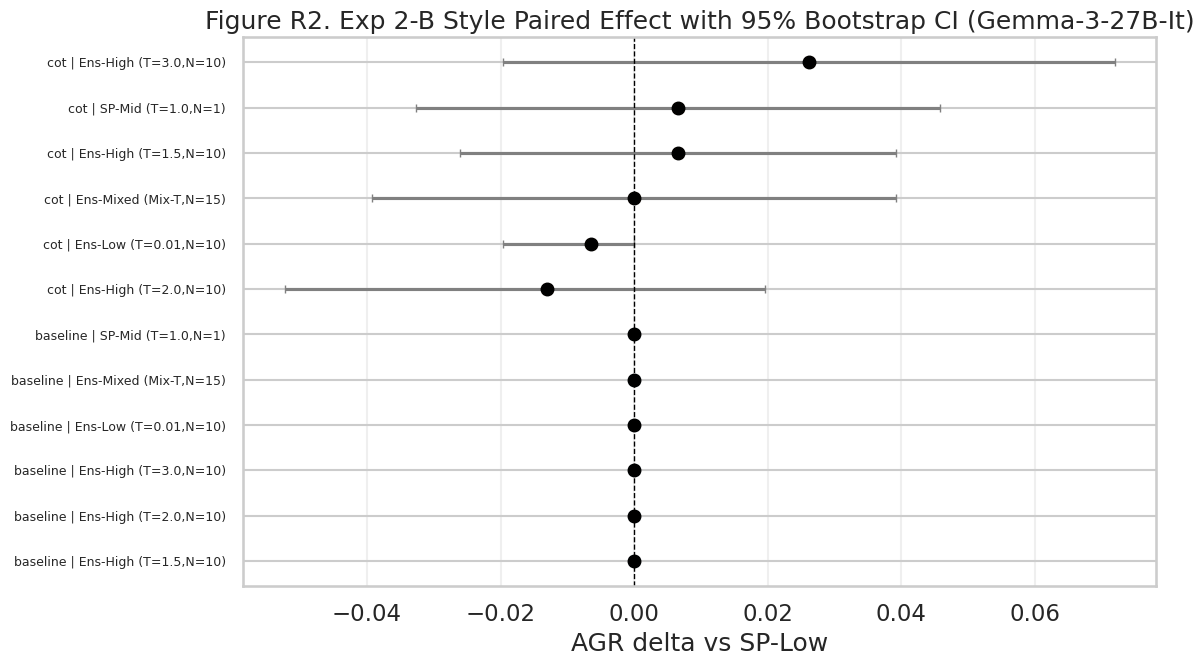

Saved: r2_sig_exp2b_forest_gemma.png


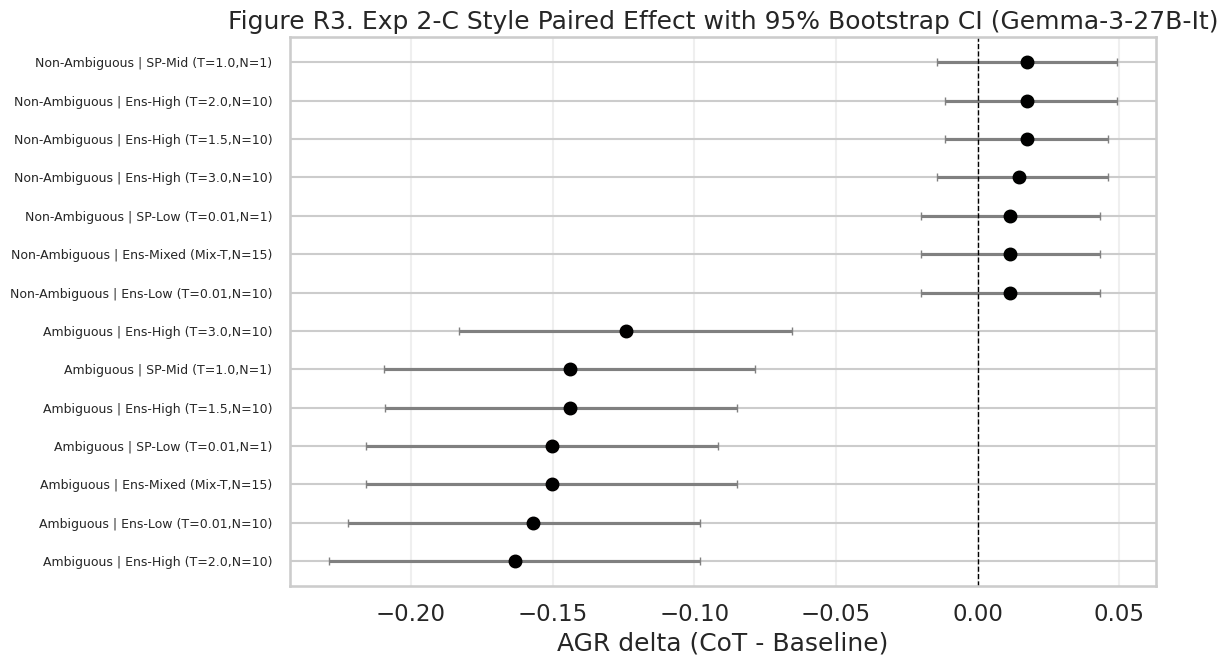

Saved: r3_sig_exp2c_forest_gemma.png


In [15]:
# Academic-style CI visualization for significance tests (2.2)
sig2b_plot = sig_2b_df[sig_2b_df['pipeline'] != 'SP-Low (T=0.01,N=1)'].copy()
sig2b_plot = sig2b_plot.sort_values(['prompt_variant', 'delta'])

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(sig2b_plot))
x = sig2b_plot['delta'].to_numpy()
xerr = np.vstack([x - sig2b_plot['ci_low'].to_numpy(), sig2b_plot['ci_high'].to_numpy() - x])
colors = sig2b_plot['prompt_variant'].map({'baseline': '#1f77b4', 'cot': '#ff7f0e'}).to_list()

ax.errorbar(x, y, xerr=xerr, fmt='o', ecolor='gray', color='black', capsize=3, linestyle='none')
for yi, xi, c in zip(y, x, colors):
    ax.scatter([xi], [yi], color=c, s=60)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels((sig2b_plot['prompt_variant'] + ' | ' + sig2b_plot['pipeline']).tolist(), fontsize=9)
ax.set_xlabel('AGR delta vs SP-Low')
ax.set_title('Figure R2. Exp 2-B Style Paired Effect with 95% Bootstrap CI (Gemma-3-27B-It)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'r2_sig_exp2b_forest_gemma.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: r2_sig_exp2b_forest_gemma.png')

sig2c_plot = sig_2c_df.copy()
sig2c_plot = sig2c_plot.sort_values(['subset', 'delta'])

fig, ax = plt.subplots(figsize=(12, 7))
y = np.arange(len(sig2c_plot))
x = sig2c_plot['delta'].to_numpy()
xerr = np.vstack([x - sig2c_plot['ci_low'].to_numpy(), sig2c_plot['ci_high'].to_numpy() - x])
colors = sig2c_plot['subset'].map({'Ambiguous': '#d62728', 'Non-Ambiguous': '#2ca02c'}).to_list()

ax.errorbar(x, y, xerr=xerr, fmt='o', ecolor='gray', color='black', capsize=3, linestyle='none')
for yi, xi, c in zip(y, x, colors):
    ax.scatter([xi], [yi], color=c, s=60)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_yticks(y)
ax.set_yticklabels((sig2c_plot['subset'] + ' | ' + sig2c_plot['pipeline']).tolist(), fontsize=9)
ax.set_xlabel('AGR delta (CoT - Baseline)')
ax.set_title('Figure R3. Exp 2-C Style Paired Effect with 95% Bootstrap CI (Gemma-3-27B-It)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / 'r3_sig_exp2c_forest_gemma.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: r3_sig_exp2c_forest_gemma.png')

## 2.4 AGR / Format-Error Separation Analysis

Report all-sample AGR, parseable-only AGR, and format error rate together.

In [16]:
def summarize_agr_err(pipe_res: dict[str, pd.DataFrame], subset_name: str, prompt_name: str) -> pd.DataFrame:
    rows = []
    for pname, dfm in pipe_res.items():
        fer = 1.0 - dfm['parseable_final'].mean()
        rows.append({
            'Subset': subset_name,
            'Prompt': prompt_name,
            'Pipeline': pname,
            'AGR_all_sample': dfm['AGR_all'].mean(),
            'AGR_parseable_only': dfm['AGR_parseable_only'].mean(),
            'Format_Error_Rate_final': fer,
            'N': len(dfm),
        })
    return pd.DataFrame(rows)

sep_tbl = pd.concat([
    summarize_agr_err(base_amb, 'Ambiguous', 'baseline'),
    summarize_agr_err(cot_amb, 'Ambiguous', 'cot'),
    summarize_agr_err(base_non, 'Non-Ambiguous', 'baseline'),
    summarize_agr_err(cot_non, 'Non-Ambiguous', 'cot'),
], ignore_index=True)

print('=== AGR vs Parseability Separation Table ===')
display(sep_tbl.round(4))

=== AGR vs Parseability Separation Table ===


,Subset,Prompt,Pipeline,AGR_all_sample,AGR_parseable_only,Format_Error_Rate_final,N
0,Ambiguous,baseline,"SP-Low (T=0.01,N=1)",0.4118,0.4118,0.0000,153
1,Ambiguous,baseline,"SP-Mid (T=1.0,N=1)",0.4118,0.4118,0.0000,153
2,Ambiguous,baseline,"Ens-Low (T=0.01,N=10)",0.4118,0.4118,0.0000,153
3,Ambiguous,baseline,"Ens-High (T=1.5,N=10)",0.4118,0.4118,0.0000,153
4,Ambiguous,baseline,"Ens-High (T=2.0,N=10)",0.4118,0.4118,0.0000,153
5,Ambiguous,baseline,"Ens-High (T=3.0,N=10)",0.4118,0.4118,0.0000,153
6,Ambiguous,baseline,"Ens-Mixed (Mix-T,N=15)",0.4118,0.4118,0.0000,153
7,Ambiguous,cot,"SP-Low (T=0.01,N=1)",0.2614,0.2614,0.0000,153
8,Ambiguous,cot,"SP-Mid (T=1.0,N=1)",0.2680,0.2680,0.0000,153
9,Ambiguous,cot,"Ens-Low (T=0.01,N=10)",0.2549,0.2549,0.0000,153


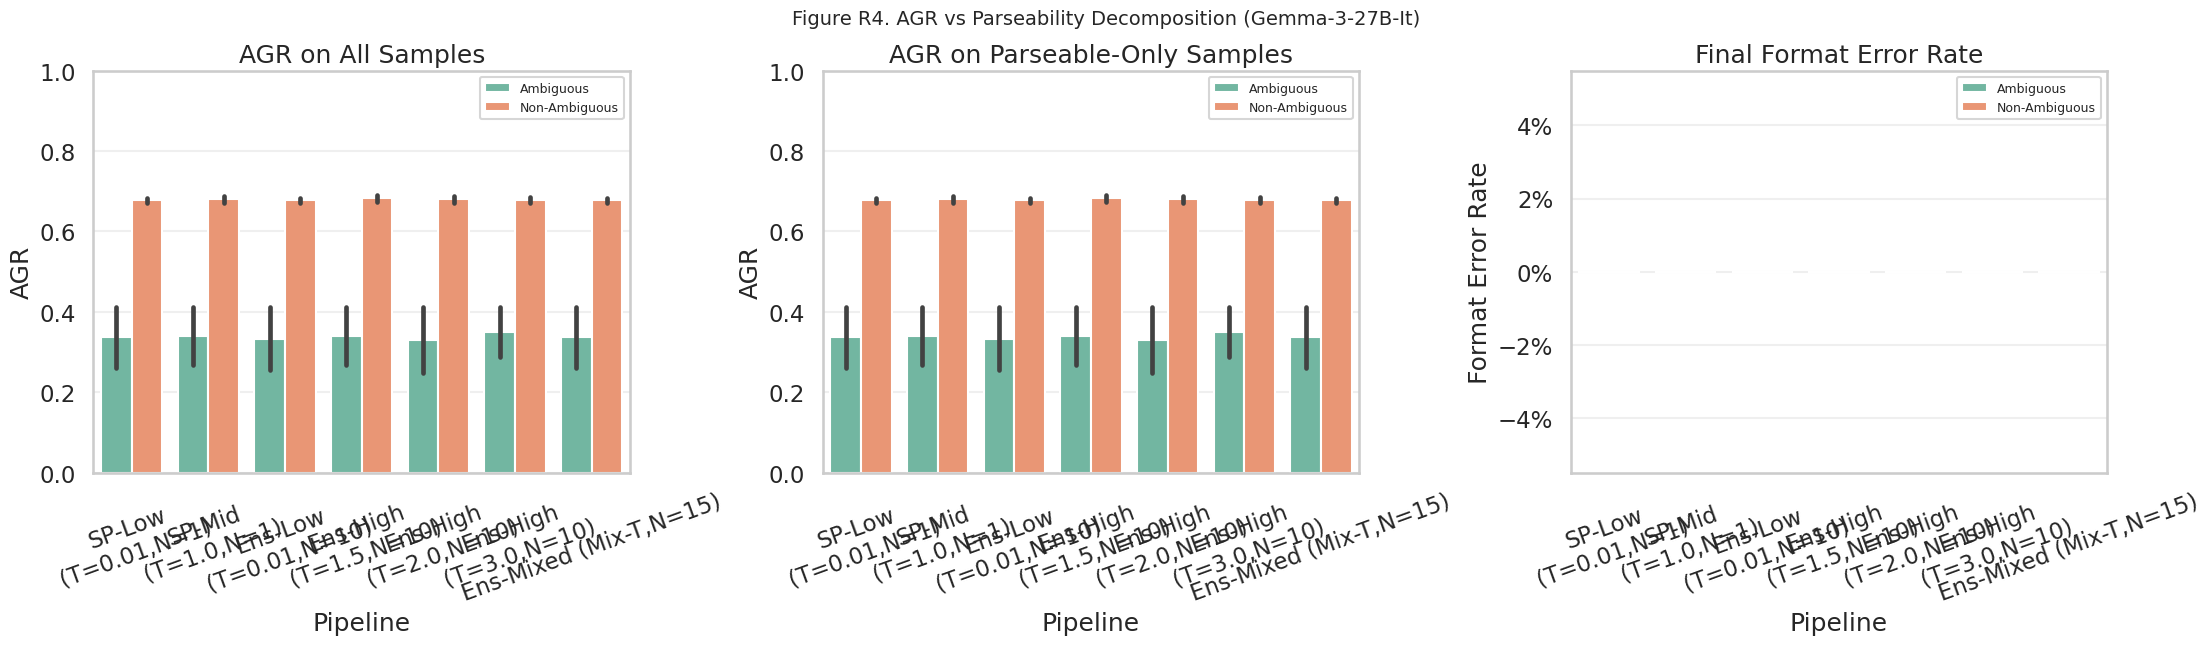

Saved: r4_agr_parseability_decomposition_gemma.png


In [17]:
# Academic-style visualization for AGR/parseability separation (2.4)
plot_sep = sep_tbl.copy()
plot_sep['PipelineShort'] = plot_sep['Pipeline'].str.replace(' (T=', '\n(T=', regex=False)

fig, axes = plt.subplots(1, 3, figsize=(22, 6), constrained_layout=True)

sns.barplot(data=plot_sep, x='PipelineShort', y='AGR_all_sample', hue='Subset', ax=axes[0], palette='Set2')
axes[0].set_title('AGR on All Samples')
axes[0].set_xlabel('Pipeline')
axes[0].set_ylabel('AGR')
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

sns.barplot(data=plot_sep, x='PipelineShort', y='AGR_parseable_only', hue='Subset', ax=axes[1], palette='Set2')
axes[1].set_title('AGR on Parseable-Only Samples')
axes[1].set_xlabel('Pipeline')
axes[1].set_ylabel('AGR')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(0, 1)
axes[1].grid(axis='y', alpha=0.3)

sns.barplot(data=plot_sep, x='PipelineShort', y='Format_Error_Rate_final', hue='Subset', ax=axes[2], palette='Set2')
axes[2].set_title('Final Format Error Rate')
axes[2].set_xlabel('Pipeline')
axes[2].set_ylabel('Format Error Rate')
axes[2].tick_params(axis='x', rotation=20)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0, decimals=0))
axes[2].grid(axis='y', alpha=0.3)

for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, fontsize=9)

fig.suptitle('Figure R4. AGR vs Parseability Decomposition (Gemma-3-27B-It)', fontsize=14, y=1.05)
plt.savefig(FIG_DIR / 'r4_agr_parseability_decomposition_gemma.png', dpi=180, bbox_inches='tight')
plt.show()
print('Saved: r4_agr_parseability_decomposition_gemma.png')

## 2.5 Human-Ambiguity Case Study (20-50 Samples)

Uses human tie questions as independent human-ambiguous set; prioritizes cases where high-T ensemble helps over SP-Low.

In [20]:
def clip_text(x: str, n: int = 240) -> str:
    x = str(x).replace('\n', ' ').strip()
    return x if len(x) <= n else x[:n] + ' ...'


def per_question_single(df_pairwise: pd.DataFrame, temp: float, repeat_id: int = 0) -> pd.DataFrame:
    s = df_pairwise[(df_pairwise['temperature'] == temp) & (df_pairwise['repeat_id'] == repeat_id)].copy()
    out = (
        s.groupby('question_id')
        .agg(
            final_verdict=('verdict', 'first'),
            gold_abc=('gold_abc', 'first'),
            parseable=('verdict', lambda x: float(pd.notna(x.iloc[0]))),
        )
        .reset_index()
    )
    out['AGR'] = ((out['final_verdict'] == out['gold_abc']) & out['final_verdict'].notna()).astype(float)
    return out


def per_question_ensemble(df_pairwise: pd.DataFrame, temp: float) -> pd.DataFrame:
    s = df_pairwise[df_pairwise['temperature'] == temp].copy()
    out = (
        s.groupby('question_id')
        .agg(
            final_verdict=('verdict', majority_verdict),
            gold_abc=('gold_abc', 'first'),
            vote_entropy=('verdict', verdict_entropy),
            format_error_rate=('format_error', lambda x: float(pd.Series(x).astype(float).mean())),
            distinct_verdicts=('verdict', lambda x: int(pd.Series(x).dropna().loc[pd.Series(x).dropna().isin(VALID_VERDICTS)].nunique())),
        )
        .reset_index()
    )
    out['parseable'] = out['final_verdict'].notna().astype(float)
    out['AGR'] = ((out['final_verdict'] == out['gold_abc']) & out['final_verdict'].notna()).astype(float)
    return out

# Task 5 core set: all low-temp failures, then check high-temp recoveries
records = []
for pv in ['baseline', 'cot']:
    pw_case = df_all[(df_all['judge_type'] == 'pairwise') & (df_all['prompt_variant'] == pv)].copy()

    low_sp = per_question_single(pw_case, temp=0.01, repeat_id=0).rename(columns={
        'AGR': 'AGR_low_sp', 'final_verdict': 'v_low_sp', 'parseable': 'parseable_low_sp'
    })

    high_single_frames = []
    for t in HIGH_SINGLE_TEMPS:
        h = per_question_single(pw_case, temp=t, repeat_id=0).rename(columns={
            'AGR': f'AGR_high_sp_{t}', 'final_verdict': f'v_high_sp_{t}', 'parseable': f'parseable_high_sp_{t}'
        })[['question_id', f'AGR_high_sp_{t}', f'v_high_sp_{t}', f'parseable_high_sp_{t}']]
        high_single_frames.append(h)

    high_ens_frames = []
    for t in HIGH_SINGLE_TEMPS:
        h = per_question_ensemble(pw_case, temp=t).rename(columns={
            'AGR': f'AGR_high_ens_{t}',
            'final_verdict': f'v_high_ens_{t}',
            'parseable': f'parseable_high_ens_{t}',
            'vote_entropy': f'ent_high_ens_{t}',
            'distinct_verdicts': f'distinct_high_ens_{t}',
        })[['question_id', f'AGR_high_ens_{t}', f'v_high_ens_{t}', f'parseable_high_ens_{t}', f'ent_high_ens_{t}', f'distinct_high_ens_{t}']]
        high_ens_frames.append(h)

    panel_pv = low_sp[['question_id', 'AGR_low_sp', 'v_low_sp', 'parseable_low_sp', 'gold_abc']].copy()
    for h in high_single_frames + high_ens_frames:
        panel_pv = panel_pv.merge(h, on='question_id', how='left')

    panel_pv['prompt_variant'] = pv

    sp_cols = [f'AGR_high_sp_{t}' for t in HIGH_SINGLE_TEMPS]
    ens_cols = [f'AGR_high_ens_{t}' for t in HIGH_SINGLE_TEMPS]
    ent_cols = [f'ent_high_ens_{t}' for t in HIGH_SINGLE_TEMPS]
    dist_cols = [f'distinct_high_ens_{t}' for t in HIGH_SINGLE_TEMPS]

    panel_pv['low_fail'] = panel_pv['AGR_low_sp'] < 1.0
    panel_pv['high_sp_success_any'] = panel_pv[sp_cols].fillna(0.0).max(axis=1) >= 1.0
    panel_pv['high_ens_success_any'] = panel_pv[ens_cols].fillna(0.0).max(axis=1) >= 1.0
    panel_pv['rescued_by_single'] = panel_pv['low_fail'] & panel_pv['high_sp_success_any']
    panel_pv['rescued_by_ensemble'] = panel_pv['low_fail'] & panel_pv['high_ens_success_any']
    panel_pv['rescued_any'] = panel_pv['low_fail'] & (panel_pv['high_sp_success_any'] | panel_pv['high_ens_success_any'])
    panel_pv['rescued_ensemble_only'] = panel_pv['low_fail'] & (~panel_pv['high_sp_success_any']) & panel_pv['high_ens_success_any']
    panel_pv['rescued_single_only'] = panel_pv['low_fail'] & panel_pv['high_sp_success_any'] & (~panel_pv['high_ens_success_any'])
    panel_pv['rescued_both'] = panel_pv['low_fail'] & panel_pv['high_sp_success_any'] & panel_pv['high_ens_success_any']
    panel_pv['not_rescued'] = panel_pv['low_fail'] & (~panel_pv['high_sp_success_any']) & (~panel_pv['high_ens_success_any'])

    panel_pv['ent_high_ens_mean'] = panel_pv[ent_cols].mean(axis=1)
    panel_pv['distinct_high_ens_mean'] = panel_pv[dist_cols].mean(axis=1)
    records.append(panel_pv)

panel = pd.concat(records, ignore_index=True)

count_tbl = pd.DataFrame([
    {'Group': 'All prompt-questions', 'Count': int(len(panel))},
    {'Group': 'Low-T failures', 'Count': int(panel['low_fail'].sum())},
    {'Group': 'Rescued by any high-T strategy', 'Count': int(panel['rescued_any'].sum())},
    {'Group': 'Rescued by high-T single-pass', 'Count': int(panel['rescued_by_single'].sum())},
    {'Group': 'Rescued by high-T ensemble', 'Count': int(panel['rescued_by_ensemble'].sum())},
    {'Group': 'Rescued by ensemble only', 'Count': int(panel['rescued_ensemble_only'].sum())},
    {'Group': 'Rescued by single only', 'Count': int(panel['rescued_single_only'].sum())},
    {'Group': 'Rescued by both', 'Count': int(panel['rescued_both'].sum())},
    {'Group': 'Low-T failures not rescued', 'Count': int(panel['not_rescued'].sum())},
])
count_tbl['Rate_among_low_fail'] = np.where(
    count_tbl['Group'].isin(['All prompt-questions', 'Low-T failures']),
    np.nan,
    count_tbl['Count'] / max(int(panel['low_fail'].sum()), 1),
)

count_by_prompt = (
    panel.groupby('prompt_variant')[['low_fail', 'rescued_any', 'rescued_by_single', 'rescued_by_ensemble']]
    .sum()
    .reset_index()
)
count_by_prompt['rescue_rate'] = count_by_prompt['rescued_any'] / count_by_prompt['low_fail'].clip(lower=1)

print('=== Task 5: Low-T Failure -> High-T Recovery Counts (Gemma-3-27B-It, baseline+cot) ===')
display(count_tbl.round(4))
print('=== Task 5: By prompt variant ===')
display(count_by_prompt.round(4))

# Attach text for qualitative review over ALL rescued examples
anchor_cases = (
    df_all[df_all['judge_type'] == 'pairwise']
    .sort_values(['question_id', 'repeat_id', 'temperature'])
    .drop_duplicates(subset=['question_id', 'prompt_variant'])
    [['question_id', 'prompt_variant', 'model_a', 'model_b', 'answer_a_text', 'answer_b_text', 'reference_answer', 'gold_winner', 'human_winner']]
    .copy()
)

rescued_all = panel[panel['rescued_any']].merge(anchor_cases, on=['question_id', 'prompt_variant'], how='left')
for c in ['answer_a_text', 'answer_b_text', 'reference_answer']:
    rescued_all[c + '_snippet'] = rescued_all[c].apply(lambda x: clip_text(x, n=260))

rescued_all = rescued_all.sort_values(['rescued_ensemble_only', 'ent_high_ens_mean'], ascending=[False, False])
save_all_rescued = OUT_DIR / 'supplementary_figures' / 'task5_all_low_fail_high_success_cases_gemma.csv'
rescued_all.to_csv(save_all_rescued, index=False)
print(f'Saved all rescued cases: {save_all_rescued}')

# Top qualitative subset for paper table
case_cols = [
    'question_id', 'prompt_variant', 'gold_winner', 'human_winner', 'v_low_sp',
    'v_high_sp_1.5', 'v_high_sp_2.0', 'v_high_sp_3.0',
    'v_high_ens_1.5', 'v_high_ens_2.0', 'v_high_ens_3.0',
    'rescued_by_single', 'rescued_by_ensemble', 'rescued_ensemble_only',
    'ent_high_ens_mean', 'distinct_high_ens_mean',
    'model_a', 'model_b',
    'answer_a_text_snippet', 'answer_b_text_snippet', 'reference_answer_snippet',
]

N_CASES = 50
case_show = rescued_all.head(N_CASES).copy()
print(f'Showing top {len(case_show)} rescued cases for qualitative analysis.')
display(case_show[case_cols])

save_top = OUT_DIR / 'supplementary_figures' / 'task5_top50_rescued_cases_gemma.csv'
case_show[case_cols].to_csv(save_top, index=False)
print(f'Saved top rescued cases: {save_top}')

=== Task 5: Low-T Failure -> High-T Recovery Counts (Gemma-3-27B-It, baseline+cot) ===


,Group,Count,Rate_among_low_fail
0,All prompt-questions,1000,NaN
1,Low-T failures,427,NaN
2,Rescued by any high-T strategy,38,0.0890
3,Rescued by high-T single-pass,34,0.0796
4,Rescued by high-T ensemble,19,0.0445
5,Rescued by ensemble only,4,0.0094
6,Rescued by single only,19,0.0445
7,Rescued by both,15,0.0351
8,Low-T failures not rescued,389,0.9110


=== Task 5: By prompt variant ===


,prompt_variant,low_fail,rescued_any,rescued_by_single,rescued_by_ensemble,rescue_rate
0,baseline,204,1,0,1,0.0049
1,cot,223,37,34,18,0.1659


Saved all rescued cases: ../output/supplementary_figures/task5_all_low_fail_high_success_cases_gemma.csv
Showing top 38 rescued cases for qualitative analysis.


,question_id,prompt_variant,gold_winner,human_winner,v_low_sp,v_high_sp_1.5,v_high_sp_2.0,v_high_sp_3.0,v_high_ens_1.5,v_high_ens_2.0,v_high_ens_3.0,rescued_by_single,rescued_by_ensemble,rescued_ensemble_only,ent_high_ens_mean,distinct_high_ens_mean,model_a,model_b,answer_a_text_snippet,answer_b_text_snippet,reference_answer_snippet
14,229,cot,model_b,model_b,C,A,C,C,C,B,C,False,True,True,1.4058,3.0000,gpt-3.5-turbo,claude-v1,If the startup maintains the same strategy for...,"* In the first year, the investment was $8000 ...","They will invest $2,000 in the third year — ha..."
34,467,cot,tie,tie,B,B,A,B,B,C,C,False,True,True,1.2310,2.6667,google/gemma-3-12b-it,Qwen/Qwen2.5-14B-Instruct,"**Final Choice:** During preschool age, childr...","The correct answer is: **Option: ""During pres...",Final Answer: J Analysis: Preschool years (ro...
0,386,baseline,model_a,model_a,C,C,C,C,A,C,C,False,True,True,0.9903,2.0000,Qwen/Qwen2.5-14B-Instruct,meta-llama/Llama-3.1-8B-Instruct,To determine the excess pressure required to c...,"To solve this problem, we need to use the equa...",Final Answer: B. 143.4 N m^-1 Analysis: For a...
6,48,cot,model_a,model_a,B,B,B,C,B,B,A,False,True,True,0.6100,2.0000,gpt-3.5-turbo,vicuna-13b-v1.2,Absolutely! A recent trip to the beautiful isl...,Aloha and welcome to my travel blog post about...,Aloha—my recent trip to Hawaii felt like stepp...
32,444,cot,model_a,model_a,B,C,A,A,A,A,A,True,True,False,1.4771,3.0000,meta-llama/Llama-3.1-8B-Instruct,google/gemma-3-12b-it,"To solve this problem, we can use the equation...",**Final Choice: 2.99 × 10^10 cm/sec** **Reaso...,Final Answer: 2.99 × 10^10 cm/sec Analysis: A...
25,396,cot,tie,tie,A,A,C,A,A,A,C,True,True,False,1.4125,3.0000,google/gemma-3-12b-it,Qwen/Qwen2.5-14B-Instruct,"**Final Choice: ""composition of the planet's c...",The most important factor in determining the h...,Final Answer: A. size of the planet Analysis:...
18,313,cot,tie,tie,A,A,A,C,A,A,C,True,True,False,1.4091,3.0000,gpt-3.5-turbo,gpt-4,"Well, I'm not exactly known for my dancing ski...","As Elon Musk, I'm not particularly known for m...","I’m not Elon Musk, but I can answer in his sty..."
33,452,cot,tie,tie,A,C,A,B,C,A,B,True,True,False,1.3961,3.0000,google/gemma-3-12b-it,Qwen/Qwen2.5-14B-Instruct,**Final Choice: B. 'A point beyond which the o...,The correct answer is: **B. A point beyond wh...,Final Answer: B. A point beyond which the outp...
4,42,cot,model_a,model_a,B,C,B,A,C,C,A,True,True,False,1.3928,3.0000,gpt-4,alpaca-13b,"{ ""IPHONE"": ""B+"", ""SAMSUNG GALAXY"": ""B"", ...","{""iPhone"": ""A"", ""Galaxy"": ""B"", ""Pixel"": ""C""}","{""IPHONE"":""A-"",""SAMSUNG GALAXY"":""B+"",""GOOGLE P..."
5,47,cot,tie,tie,A,A,A,C,A,A,C,True,True,False,1.3806,3.0000,gpt-3.5-turbo,gpt-4,"Well, I'm not exactly known for my dancing ski...","As Elon Musk, I'm not particularly known for m...",Speaking in the style of Elon Musk (I’m not ac...


Saved top rescued cases: ../output/supplementary_figures/task5_top50_rescued_cases_gemma.csv


=== Task 5: Linguistic and uncertainty feature analysis (Low-fail cohort) ===


,Feature,Mean (Rescued),Mean (Not Rescued),Delta (Rescued-Not),SMD,p_value_MWU
0,distinct_high_ens_mean,2.1754,1.2631,0.9124,2.0547,0.0000
1,ent_high_ens_mean,0.8197,0.1706,0.6491,2.0943,0.0000
2,has_math_like,0.3158,0.1440,0.1718,0.4727,0.0058
3,lex_overlap,0.3058,0.2647,0.0411,0.3212,0.1024
4,has_hedge,0.1842,0.2802,-0.0960,-0.2157,0.2050
5,question_density,0.0000,0.0001,-0.0001,-0.1922,0.2154
6,has_code_like,0.1316,0.2108,-0.0792,-0.1965,0.2482
7,avg_len,751.2632,850.6979,-99.4348,-0.1572,0.4401
8,len_ratio_close,0.6112,0.5736,0.0376,0.1379,0.4989
9,has_number,0.6842,0.6581,0.0261,0.0550,0.7465


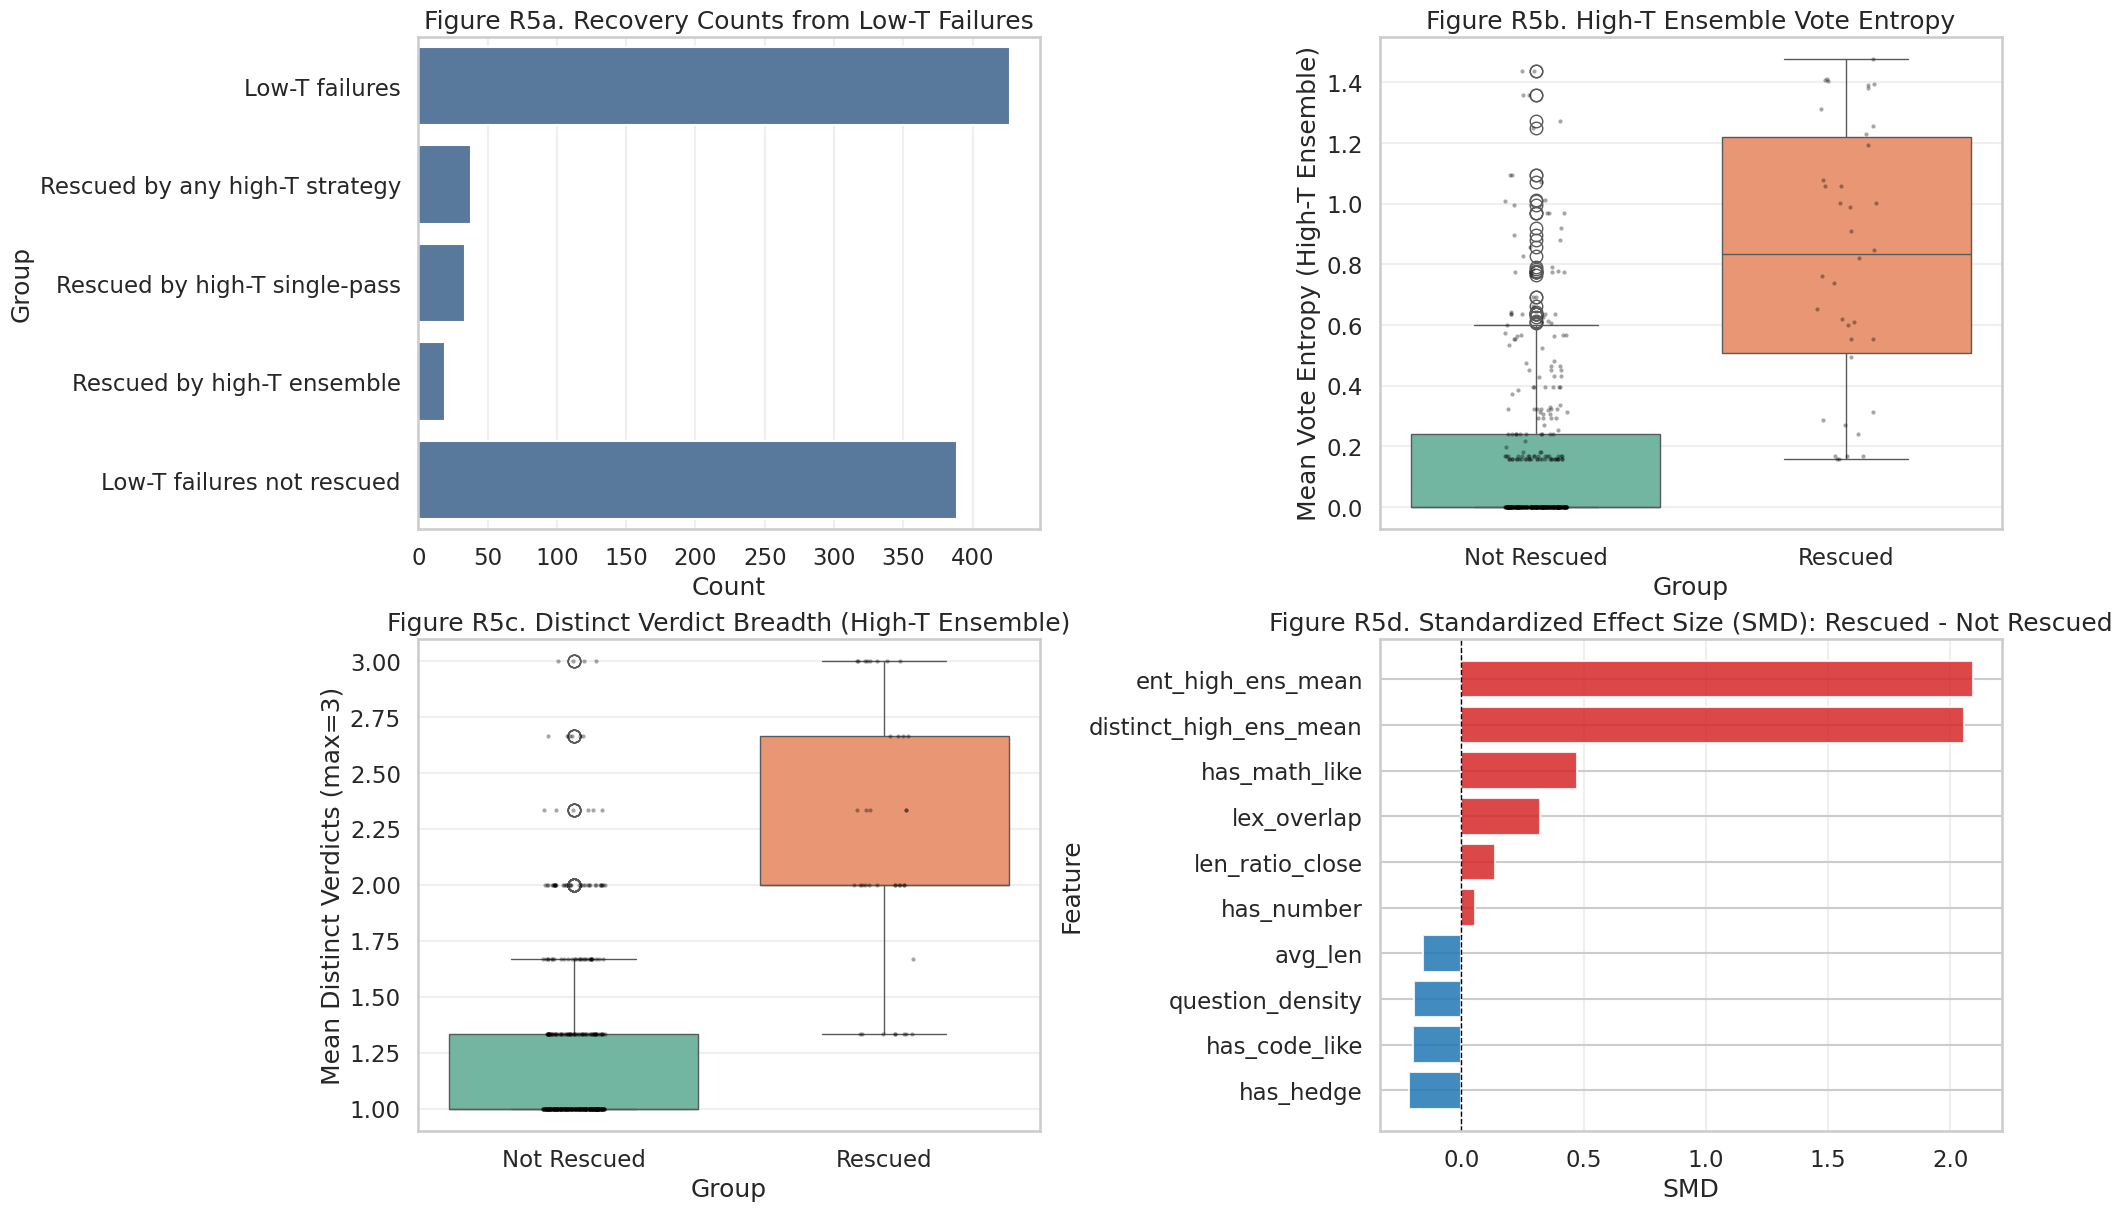

Saved: r5_low_fail_recovery_analysis_gemma.png
Saved: ../output/supplementary_figures/task5_feature_stats_gemma.csv


In [22]:
# Task 5 advanced quantitative + qualitative analysis and visualization
HEDGE_RE = re.compile(r'\b(maybe|perhaps|possibly|might|could|likely|uncertain|arguably|plausible)\b', re.IGNORECASE)
NUM_RE = re.compile(r'\d')
CODE_RE = re.compile(r'```|def\s+|class\s+|import\s+|for\s+\w+\s+in', re.IGNORECASE)
MATH_RE = re.compile(r'\$|\\\(|\\\)|\\frac|\\sum|\\int|\btheorem\b|\bproof\b', re.IGNORECASE)

def ling_features(a: str, b: str) -> dict:
    ta = str(a)
    tb = str(b)
    both = ta + ' ' + tb
    len_a = len(ta)
    len_b = len(tb)
    return {
        'avg_len': (len_a + len_b) / 2.0,
        'len_ratio_close': (min(len_a, len_b) / max(len_a, len_b, 1)),
        'lex_overlap': jaccard(ta, tb),
        'has_hedge': float(bool(HEDGE_RE.search(both))),
        'has_number': float(bool(NUM_RE.search(both))),
        'has_code_like': float(bool(CODE_RE.search(both))),
        'has_math_like': float(bool(MATH_RE.search(both))),
        'question_density': both.count('?') / max(len(both), 1),
    }

# Build low-failure cohort and compare rescued vs non-rescued
low_fail_pool = panel[panel['low_fail']].merge(anchor_cases, on=['question_id', 'prompt_variant'], how='left').copy()
low_fail_pool['rescued_flag'] = low_fail_pool['rescued_any'].astype(int)

feat_rows = []
for _, r in low_fail_pool.iterrows():
    d = ling_features(r.get('answer_a_text', ''), r.get('answer_b_text', ''))
    d['question_id'] = r['question_id']
    d['prompt_variant'] = r['prompt_variant']
    d['rescued_flag'] = int(r['rescued_flag'])
    d['rescued_label'] = 'Rescued' if r['rescued_flag'] == 1 else 'Not Rescued'
    d['ent_high_ens_mean'] = r.get('ent_high_ens_mean', np.nan)
    d['distinct_high_ens_mean'] = r.get('distinct_high_ens_mean', np.nan)
    feat_rows.append(d)

feat_df = pd.DataFrame(feat_rows)

cont_features = [
    'avg_len', 'len_ratio_close', 'lex_overlap', 'question_density',
    'ent_high_ens_mean', 'distinct_high_ens_mean',
]
bin_features = ['has_hedge', 'has_number', 'has_code_like', 'has_math_like']

stat_rows = []
for col in cont_features + bin_features:
    g1 = feat_df.loc[feat_df['rescued_flag'] == 1, col].dropna()
    g0 = feat_df.loc[feat_df['rescued_flag'] == 0, col].dropna()
    m1 = float(g1.mean()) if len(g1) else np.nan
    m0 = float(g0.mean()) if len(g0) else np.nan
    delta = float(m1 - m0) if len(g1) and len(g0) else np.nan
    if len(g1) > 1 and len(g0) > 1:
        p = stats.mannwhitneyu(g1, g0, alternative='two-sided').pvalue
        s1 = float(g1.std(ddof=1))
        s0 = float(g0.std(ddof=1))
        pooled = np.sqrt(((len(g1)-1)*(s1**2) + (len(g0)-1)*(s0**2)) / max(len(g1)+len(g0)-2, 1))
        smd = float(delta / pooled) if pooled > 0 else np.nan
    else:
        p = np.nan
        smd = np.nan
    stat_rows.append({
        'Feature': col,
        'Mean (Rescued)': m1,
        'Mean (Not Rescued)': m0,
        'Delta (Rescued-Not)': delta,
        'SMD': smd,
        'p_value_MWU': p,
    })

task5_stats_tbl = pd.DataFrame(stat_rows).sort_values('p_value_MWU', na_position='last').reset_index(drop=True)
print('=== Task 5: Linguistic and uncertainty feature analysis (Low-fail cohort) ===')
display(task5_stats_tbl.round(5))

fig = plt.figure(figsize=(20, 12), constrained_layout=True)
gs = fig.add_gridspec(2, 2)

ax1 = fig.add_subplot(gs[0, 0])
count_plot = count_tbl[count_tbl['Group'].isin([
    'Low-T failures', 'Rescued by any high-T strategy', 'Rescued by high-T single-pass',
    'Rescued by high-T ensemble', 'Low-T failures not rescued'
])].copy()
sns.barplot(data=count_plot, y='Group', x='Count', color='#4C78A8', ax=ax1)
ax1.set_title('Figure R5a. Recovery Counts from Low-T Failures')
ax1.set_xlabel('Count')
ax1.set_ylabel('Group')
ax1.grid(axis='x', alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=feat_df, x='rescued_label', y='ent_high_ens_mean', hue='rescued_label', dodge=False, palette='Set2', ax=ax2, legend=False)
sns.stripplot(data=feat_df, x='rescued_label', y='ent_high_ens_mean', color='black', alpha=0.35, size=3, ax=ax2)
ax2.set_title('Figure R5b. High-T Ensemble Vote Entropy')
ax2.set_xlabel('Group')
ax2.set_ylabel('Mean Vote Entropy (High-T Ensemble)')
ax2.grid(axis='y', alpha=0.3)

ax3 = fig.add_subplot(gs[1, 0])
sns.boxplot(data=feat_df, x='rescued_label', y='distinct_high_ens_mean', hue='rescued_label', dodge=False, palette='Set2', ax=ax3, legend=False)
sns.stripplot(data=feat_df, x='rescued_label', y='distinct_high_ens_mean', color='black', alpha=0.35, size=3, ax=ax3)
ax3.set_title('Figure R5c. Distinct Verdict Breadth (High-T Ensemble)')
ax3.set_xlabel('Group')
ax3.set_ylabel('Mean Distinct Verdicts (max=3)')
ax3.grid(axis='y', alpha=0.3)

ax4 = fig.add_subplot(gs[1, 1])
effect_plot = task5_stats_tbl[['Feature', 'SMD']].dropna().sort_values('SMD')
colors = ['#D62728' if x > 0 else '#1F77B4' for x in effect_plot['SMD']]
ax4.barh(effect_plot['Feature'], effect_plot['SMD'], color=colors, alpha=0.85)
ax4.axvline(0, color='black', linestyle='--', linewidth=1)
ax4.set_title('Figure R5d. Standardized Effect Size (SMD): Rescued - Not Rescued')
ax4.set_xlabel('SMD')
ax4.set_ylabel('Feature')
ax4.grid(axis='x', alpha=0.3)

plt.savefig(FIG_DIR / 'r5_low_fail_recovery_analysis_gemma.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: r5_low_fail_recovery_analysis_gemma.png')

save_task5_stats = OUT_DIR / 'supplementary_figures' / 'task5_feature_stats_gemma.csv'
task5_stats_tbl.to_csv(save_task5_stats, index=False)
print(f'Saved: {save_task5_stats}')

## Optional: Minimal top_p=1.0 Run Template

Use this only when `top_p=1.0` files do not exist yet. It runs a small key-temperature setup.

In [ ]:
# Fill in your endpoint/model, then run in terminal (recommended):
# uv run llmjudge run -m <MODEL_NAME> -u <BASE_URL> -b vllm -s <SIZE_LABEL> \
#   -t 0.01,1.0,1.5,2.0,3.0 -j pairwise -p baseline,cot -r 10 -n 300 --top-p 1.0 \
#   -o output/top_p_ablation/<RUN_NAME>

print('Template only. After run finishes, export to JSONL with metrics and add files to RESULT_FILE_MAP[1.0].')

In [43]:
# Direct vs CoT table under NEW ambiguous definition (independent ambiguity subset)
# Uses amb_qids / nonamb_qids from Cell 8.

pw_095_new = df_all[(df_all['judge_type'] == 'pairwise') & (df_all['top_p'] == 0.95)].copy()
pw_base_new = pw_095_new[pw_095_new['prompt_variant'] == 'baseline'].copy()
pw_cot_new = pw_095_new[pw_095_new['prompt_variant'] == 'cot'].copy()

def run_pipelines_qid_subset(pw_prompt: pd.DataFrame, qid_set: set[int]) -> dict[str, pd.DataFrame]:
    sub0 = pw_prompt[pw_prompt['question_id'].isin(qid_set)].copy()
    out = {}
    for name, cfg in PIPELINES.items():
        x = sub0[sub0['temperature'].isin(cfg['temps']) & sub0['repeat_id'].isin(cfg['repeats'])].copy()
        out[name] = compute_pipeline_metrics_exp2(x, cfg['agg'])
    return out

base_amb_new = run_pipelines_qid_subset(pw_base_new, amb_qids)
base_non_new = run_pipelines_qid_subset(pw_base_new, nonamb_qids)
cot_amb_new = run_pipelines_qid_subset(pw_cot_new, amb_qids)
cot_non_new = run_pipelines_qid_subset(pw_cot_new, nonamb_qids)

def build_rows_new(prompt_label: str, res_amb: dict[str, pd.DataFrame], res_non: dict[str, pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for pname in PIPELINES.keys():
        d_amb = res_amb[pname]
        d_non = res_non[pname]
        rows.append({
            'Prompt': prompt_label,
            'Pipeline': pname,
            'AGR (Amb)': d_amb['AGR'].mean() if len(d_amb) else np.nan,
            'AGR (Non-Amb)': d_non['AGR'].mean() if len(d_non) else np.nan,
            'N_Amb': len(d_amb),
            'N_NonAmb': len(d_non),
        })
    return pd.DataFrame(rows)

exp2_block_newamb = pd.concat([
    build_rows_new('Direct', base_amb_new, base_non_new),
    build_rows_new('Chain-of-Thought', cot_amb_new, cot_non_new),
], ignore_index=True)

prompt_order = ['Direct', 'Chain-of-Thought']
pipe_order = list(PIPELINES.keys())
exp2_block_newamb['Prompt'] = pd.Categorical(exp2_block_newamb['Prompt'], categories=prompt_order, ordered=True)
exp2_block_newamb['Pipeline'] = pd.Categorical(exp2_block_newamb['Pipeline'], categories=pipe_order, ordered=True)
exp2_block_newamb = exp2_block_newamb.sort_values(['Prompt', 'Pipeline']).reset_index(drop=True)

print('=== Direct vs CoT on NEW ambiguous definition (AGR) ===')
print(f"Ambiguous qids: {len(amb_qids)} | Non-ambiguous qids: {len(nonamb_qids)}")
display(exp2_block_newamb.round(4))

# Build markdown text for copy/paste
md_lines = []
md_lines.append('### Direct vs CoT on NEW ambiguous definition (AGR)')
md_lines.append('')
md_lines.append('| Prompt | Pipeline | AGR (Amb) | AGR (Non-Amb) | N_Amb | N_NonAmb |')
md_lines.append('|---|---|---:|---:|---:|---:|')
for _, r in exp2_block_newamb.iterrows():
    md_lines.append(
        f"| {r['Prompt']} | {r['Pipeline']} | {r['AGR (Amb)']:.4f} | {r['AGR (Non-Amb)']:.4f} | {int(r['N_Amb'])} | {int(r['N_NonAmb'])} |"
    )

md_newamb_table = '\n'.join(md_lines)
print('\n' + md_newamb_table)

=== Direct vs CoT on NEW ambiguous definition (AGR) ===
Ambiguous qids: 153 | Non-ambiguous qids: 347


,Prompt,Pipeline,AGR (Amb),AGR (Non-Amb),N_Amb,N_NonAmb
0,Direct,"SP-Low (T=0.01,N=1)",0.3725,0.6945,306,694
1,Direct,"SP-Mid (T=1.0,N=1)",0.3529,0.6988,306,694
2,Direct,"Ens-Low (T=0.01,N=10)",0.3791,0.6988,306,694
3,Direct,"Ens-High (T=1.5,N=10)",0.3824,0.6945,306,694
4,Direct,"Ens-High (T=2.0,N=10)",0.3987,0.6931,306,694
5,Direct,"Ens-High (T=3.0,N=10)",0.4118,0.6830,306,694
6,Direct,"Ens-Mixed (Mix-T,N=15)",0.3627,0.6960,306,694
7,Chain-of-Thought,"SP-Low (T=0.01,N=1)",0.2678,0.6938,306,694
8,Chain-of-Thought,"SP-Mid (T=1.0,N=1)",0.2509,0.6992,306,694
9,Chain-of-Thought,"Ens-Low (T=0.01,N=10)",0.2673,0.7006,306,694



### Direct vs CoT on NEW ambiguous definition (AGR)

| Prompt | Pipeline | AGR (Amb) | AGR (Non-Amb) | N_Amb | N_NonAmb |
|---|---|---:|---:|---:|---:|
| Direct | SP-Low (T=0.01,N=1) | 0.3725 | 0.6945 | 306 | 694 |
| Direct | SP-Mid (T=1.0,N=1) | 0.3529 | 0.6988 | 306 | 694 |
| Direct | Ens-Low (T=0.01,N=10) | 0.3791 | 0.6988 | 306 | 694 |
| Direct | Ens-High (T=1.5,N=10) | 0.3824 | 0.6945 | 306 | 694 |
| Direct | Ens-High (T=2.0,N=10) | 0.3987 | 0.6931 | 306 | 694 |
| Direct | Ens-High (T=3.0,N=10) | 0.4118 | 0.6830 | 306 | 694 |
| Direct | Ens-Mixed (Mix-T,N=15) | 0.3627 | 0.6960 | 306 | 694 |
| Chain-of-Thought | SP-Low (T=0.01,N=1) | 0.2678 | 0.6938 | 306 | 694 |
| Chain-of-Thought | SP-Mid (T=1.0,N=1) | 0.2509 | 0.6992 | 306 | 694 |
| Chain-of-Thought | Ens-Low (T=0.01,N=10) | 0.2673 | 0.7006 | 306 | 694 |
| Chain-of-Thought | Ens-High (T=1.5,N=10) | 0.2778 | 0.7042 | 306 | 694 |
| Chain-of-Thought | Ens-High (T=2.0,N=10) | 0.2745 | 0.6960 | 306 | 694 |
| Chain-of-Thought | Ens-H

In [45]:
# Significance test with ORIGINAL ambiguous set (entropy-based AMB_IDS/NONAMB_IDS)
# Separate from the new independent ambiguous definition (amb_qids/nonamb_qids).

pw_base_orig = df_all[(df_all['judge_type'] == 'pairwise') & (df_all['prompt_variant'] == 'baseline') & (df_all['top_p'] == 0.95)].copy()
pw_cot_orig = df_all[(df_all['judge_type'] == 'pairwise') & (df_all['prompt_variant'] == 'cot') & (df_all['top_p'] == 0.95)].copy()

base_amb_orig = build_pipe_results(pw_base_orig, AMB_IDS)
base_non_orig = build_pipe_results(pw_base_orig, NONAMB_IDS)
cot_amb_orig = build_pipe_results(pw_cot_orig, AMB_IDS)
cot_non_orig = build_pipe_results(pw_cot_orig, NONAMB_IDS)

# Exp 2-B style (original ambiguous set): pipeline AGR_all vs SP-Low within same prompt/subset
sig_2b_orig = []
for prompt_name, res_dict in [('baseline', base_amb_orig), ('cot', cot_amb_orig)]:
    ref = res_dict['SP-Low (T=0.01,N=1)'].set_index(['question_id', 'judge_model'])['AGR_all']
    for pname, r in res_dict.items():
        cur = r.set_index(['question_id', 'judge_model'])['AGR_all']
        st = paired_bootstrap_and_ttest(cur, ref)
        st.update({'prompt_variant': prompt_name, 'subset': 'Ambiguous(orig)', 'pipeline': pname, 'vs_ref': 'SP-Low'})
        sig_2b_orig.append(st)

sig_2b_orig_df = pd.DataFrame(sig_2b_orig).sort_values(['prompt_variant', 'pipeline']).reset_index(drop=True)

# Exp 2-C style (original ambiguous set): CoT - Baseline per pipeline, same subset
sig_2c_orig = []
for subset_name, base_res, cot_res in [('Ambiguous(orig)', base_amb_orig, cot_amb_orig), ('Non-Ambiguous(orig)', base_non_orig, cot_non_orig)]:
    for pname in PIPELINES.keys():
        b = base_res[pname].set_index(['question_id', 'judge_model'])['AGR_all']
        c = cot_res[pname].set_index(['question_id', 'judge_model'])['AGR_all']
        st = paired_bootstrap_and_ttest(c, b)
        st.update({'subset': subset_name, 'pipeline': pname, 'contrast': 'CoT - Baseline'})
        sig_2c_orig.append(st)

sig_2c_orig_df = pd.DataFrame(sig_2c_orig).sort_values(['subset', 'pipeline']).reset_index(drop=True)

print('=== ORIGINAL ambiguous set significance (using AMB_IDS/NONAMB_IDS) ===')
print(f"Ambiguous question IDs: {len(AMB_IDS)} | Non-Ambiguous question IDs: {len(NONAMB_IDS)}")
print('\n=== Exp 2-B style (original ambiguous set) ===')
display(sig_2b_orig_df.round(4))
print('\n=== Exp 2-C style (original ambiguous set) ===')
display(sig_2c_orig_df.round(4))

=== ORIGINAL ambiguous set significance (using AMB_IDS/NONAMB_IDS) ===
Ambiguous question IDs: 213 | Non-Ambiguous question IDs: 287

=== Exp 2-B style (original ambiguous set) ===


,n,delta,ci_low,ci_high,p_ttest,prompt_variant,subset,pipeline,vs_ref
0,426,0.0094,-0.0047,0.0235,0.2063,baseline,Ambiguous(orig),"Ens-High (T=1.5,N=10)",SP-Low
1,426,0.0164,0.0000,0.0329,0.0521,baseline,Ambiguous(orig),"Ens-High (T=2.0,N=10)",SP-Low
2,426,0.0117,-0.0117,0.0352,0.3365,baseline,Ambiguous(orig),"Ens-High (T=3.0,N=10)",SP-Low
3,426,0.0047,0.0000,0.0117,0.1575,baseline,Ambiguous(orig),"Ens-Low (T=0.01,N=10)",SP-Low
4,426,-0.0070,-0.0188,0.0047,0.2573,baseline,Ambiguous(orig),"Ens-Mixed (Mix-T,N=15)",SP-Low
5,426,0.0000,0.0000,0.0000,NaN,baseline,Ambiguous(orig),"SP-Low (T=0.01,N=1)",SP-Low
6,426,-0.0047,-0.0258,0.0164,0.6703,baseline,Ambiguous(orig),"SP-Mid (T=1.0,N=1)",SP-Low
7,426,0.0446,0.0164,0.0751,0.0029,cot,Ambiguous(orig),"Ens-High (T=1.5,N=10)",SP-Low
8,426,0.0423,0.0117,0.0751,0.0078,cot,Ambiguous(orig),"Ens-High (T=2.0,N=10)",SP-Low
9,426,0.0610,0.0235,0.0986,0.0018,cot,Ambiguous(orig),"Ens-High (T=3.0,N=10)",SP-Low



=== Exp 2-C style (original ambiguous set) ===


,n,delta,ci_low,ci_high,p_ttest,subset,pipeline,contrast
0,426,-0.0728,-0.1127,-0.0329,0.0003,Ambiguous(orig),"Ens-High (T=1.5,N=10)",CoT - Baseline
1,426,-0.0822,-0.1244,-0.0399,0.0002,Ambiguous(orig),"Ens-High (T=2.0,N=10)",CoT - Baseline
2,426,-0.0587,-0.1056,-0.0117,0.0155,Ambiguous(orig),"Ens-High (T=3.0,N=10)",CoT - Baseline
3,426,-0.0681,-0.1080,-0.0282,0.0010,Ambiguous(orig),"Ens-Low (T=0.01,N=10)",CoT - Baseline
4,426,-0.1033,-0.1479,-0.0587,0.0000,Ambiguous(orig),"Ens-Mixed (Mix-T,N=15)",CoT - Baseline
5,426,-0.1080,-0.1549,-0.0634,0.0000,Ambiguous(orig),"SP-Low (T=0.01,N=1)",CoT - Baseline
6,426,-0.1362,-0.1831,-0.0892,0.0000,Ambiguous(orig),"SP-Mid (T=1.0,N=1)",CoT - Baseline
7,574,0.0087,-0.0035,0.0209,0.1970,Non-Ambiguous(orig),"Ens-High (T=1.5,N=10)",CoT - Baseline
8,574,-0.0017,-0.0157,0.0139,0.8188,Non-Ambiguous(orig),"Ens-High (T=2.0,N=10)",CoT - Baseline
9,574,-0.0157,-0.0348,0.0017,0.0947,Non-Ambiguous(orig),"Ens-High (T=3.0,N=10)",CoT - Baseline
